# Week 5 - clustering the people behind the mailboxes

The week-4 report established that a mailbox folder is not a person: addresses
have to be resolved to owners before the social plots count people rather than
spellings. This week we take the 149 resolved owners and ask whether they fall
into groups by *how* they use mail (a behavioural clustering and its hierarchy)
and by *what* they write about (a content clustering), and how those two views
relate to the social communities found last week. The body-to-group prediction
the schedule turns to next is set up at the end.

Everything runs on the cleaned, deduplicated dataset under `eda-5/clean/`, which
now carries a `sender_person` column resolving each message to the owner who
wrote it (and `recipient_person` on the recipient side). See the report for the
identity-resolution fix that produced it.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import math

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind", font_scale=1.3)
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 13,
    "figure.titlesize": 18,
})

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
PLOTS = ROOT / "eda-5" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
CLEAN = ROOT / "eda-5" / "clean"

msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
people = pd.read_parquet(CLEAN / "people.parquet")

print(f"unique messages:        {len(msg):>9,}")
print(f"mailbox owners:         {msg['mailbox_owner'].nunique():>9}")
print(f"messages with a resolved author: {msg['sender_person'].notna().sum():>9,} "
      f"({msg['sender_person'].notna().mean():.1%})")
print(f"owners recovered from non-sent folders: "
      f"{people.loc[people.resolved_via=='recovered_nonsent','owner'].tolist()}")

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import Image as _PNG, display as _show

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#7a5ea6"

pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white", colorway=[BLUE, ORANGE, GREEN, RED],
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14)),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14)),
    legend=dict(font=dict(size=15)),
))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h,
                      margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    from PIL import Image as _PILImage
    _im = _PILImage.open(out); _im.save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

def save_mpl(fig, name, dpi=200):
    out = PLOTS / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    _show(_PNG(filename=str(out)))
    plt.close(fig)

def disp(handle):
    "kaminski-v -> 'Kaminski V'"
    sn, _, ini = handle.partition("-")
    return f"{sn.replace('.', ' ').title()} {ini.upper()}".strip()

unique messages:          252,022
mailbox owners:               149
messages with a resolved author:   107,670 (42.7%)
owners recovered from non-sent folders: ['harris-s', 'stokley-c']


## From mailboxes to people, and the features that describe them

We profile every owner with at least 30 messages we can attribute to them as the
author (`sender_person`). That is 143 of the 149 owners; the six below the floor
are near-empty mailboxes whose feature ratios would be noise. For each person we
build a vector of twelve features that describe communication *behaviour*, not
content: how much they send, how long their messages are, how many people they
write to at once, how much of their mail leaves the company, how often they open
a thread rather than reply, how concentrated their activity is, how long they are
active, how much of their mailbox is deleted, and their in/out degree in the
internal people-graph. Counts that span orders of magnitude are log-scaled so a
handful of heavy senders do not dominate the distance, then every feature is
standardised so each contributes on the same footing.

In [2]:
MIN_AUTHORED = 30
authored = msg[msg["sender_person"].notna()].copy()
ac = authored.groupby("sender_person").size()
keep = sorted(ac[ac >= MIN_AUTHORED].index)
dropped = sorted(ac[ac < MIN_AUTHORED].index)
print(f"owners profiled (>= {MIN_AUTHORED} authored): {len(keep)}   "
      f"below floor (dropped): {dropped}")

a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g = authored.groupby("sender_person")
ag = a.groupby("sender_person")

F = pd.DataFrame(index=keep)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep)

# people-graph degree, using the resolved persons on both ends
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"]
        & ~ei["recipient_is_list"] & ~ei["is_self"]
        & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep)

F = F.reindex(keep).fillna(F.median())
Fraw = F.copy()
LOGCOLS = ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]
for c in LOGCOLS:
    F[c] = np.log1p(F[c])

PRETTY = {
    "n_sent": "messages sent", "med_len": "median body length",
    "mean_recip": "recipients per message", "ext_ratio": "share external",
    "cc_ratio": "Cc share", "broadcast": "share to >5 people",
    "root_ratio": "thread-opening share", "wknd_ratio": "weekend share",
    "active_months": "active months", "del_rate": "mailbox deletion rate",
    "out_deg": "people written to", "in_deg": "people writing in",
}
X = StandardScaler().fit_transform(F.values)
print("feature matrix:", X.shape)
print(Fraw.describe().round(2).T[["mean", "min", "50%", "max"]])

owners profiled (>= 30 authored): 143   below floor (dropped): ['benson-r', 'king-j', 'linder-e', 'merriss-s', 'motley-m', 'south-s']


feature matrix: (143, 12)
                 mean    min     50%      max
n_sent         752.20  30.00  427.00  5511.00
med_len        122.19   0.00  107.00   519.50
mean_recip       2.38   0.98    1.68    19.45
ext_ratio        0.29   0.02    0.24     0.94
cc_ratio         0.13   0.00    0.11     0.44
broadcast        0.06   0.00    0.03     0.38
root_ratio       0.60   0.29    0.59     0.97
wknd_ratio       0.03   0.00    0.01     0.34
active_months   20.90   2.96   20.27    57.82
del_rate         0.20   0.00    0.15     0.97
out_deg         18.39   1.00   15.00    83.00
in_deg          18.10   4.00   17.00    49.00


### The features are only loosely redundant

Before clustering, a quick look at how the twelve features co-vary. Volume,
reach and degree move together (a person who sends a lot tends to write to and
hear from many people), which is why the counts are log-scaled and standardised
rather than fed in raw. But most pairs are weakly correlated, so the vector is
not secretly one-dimensional and there is real structure for a clustering to
find.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


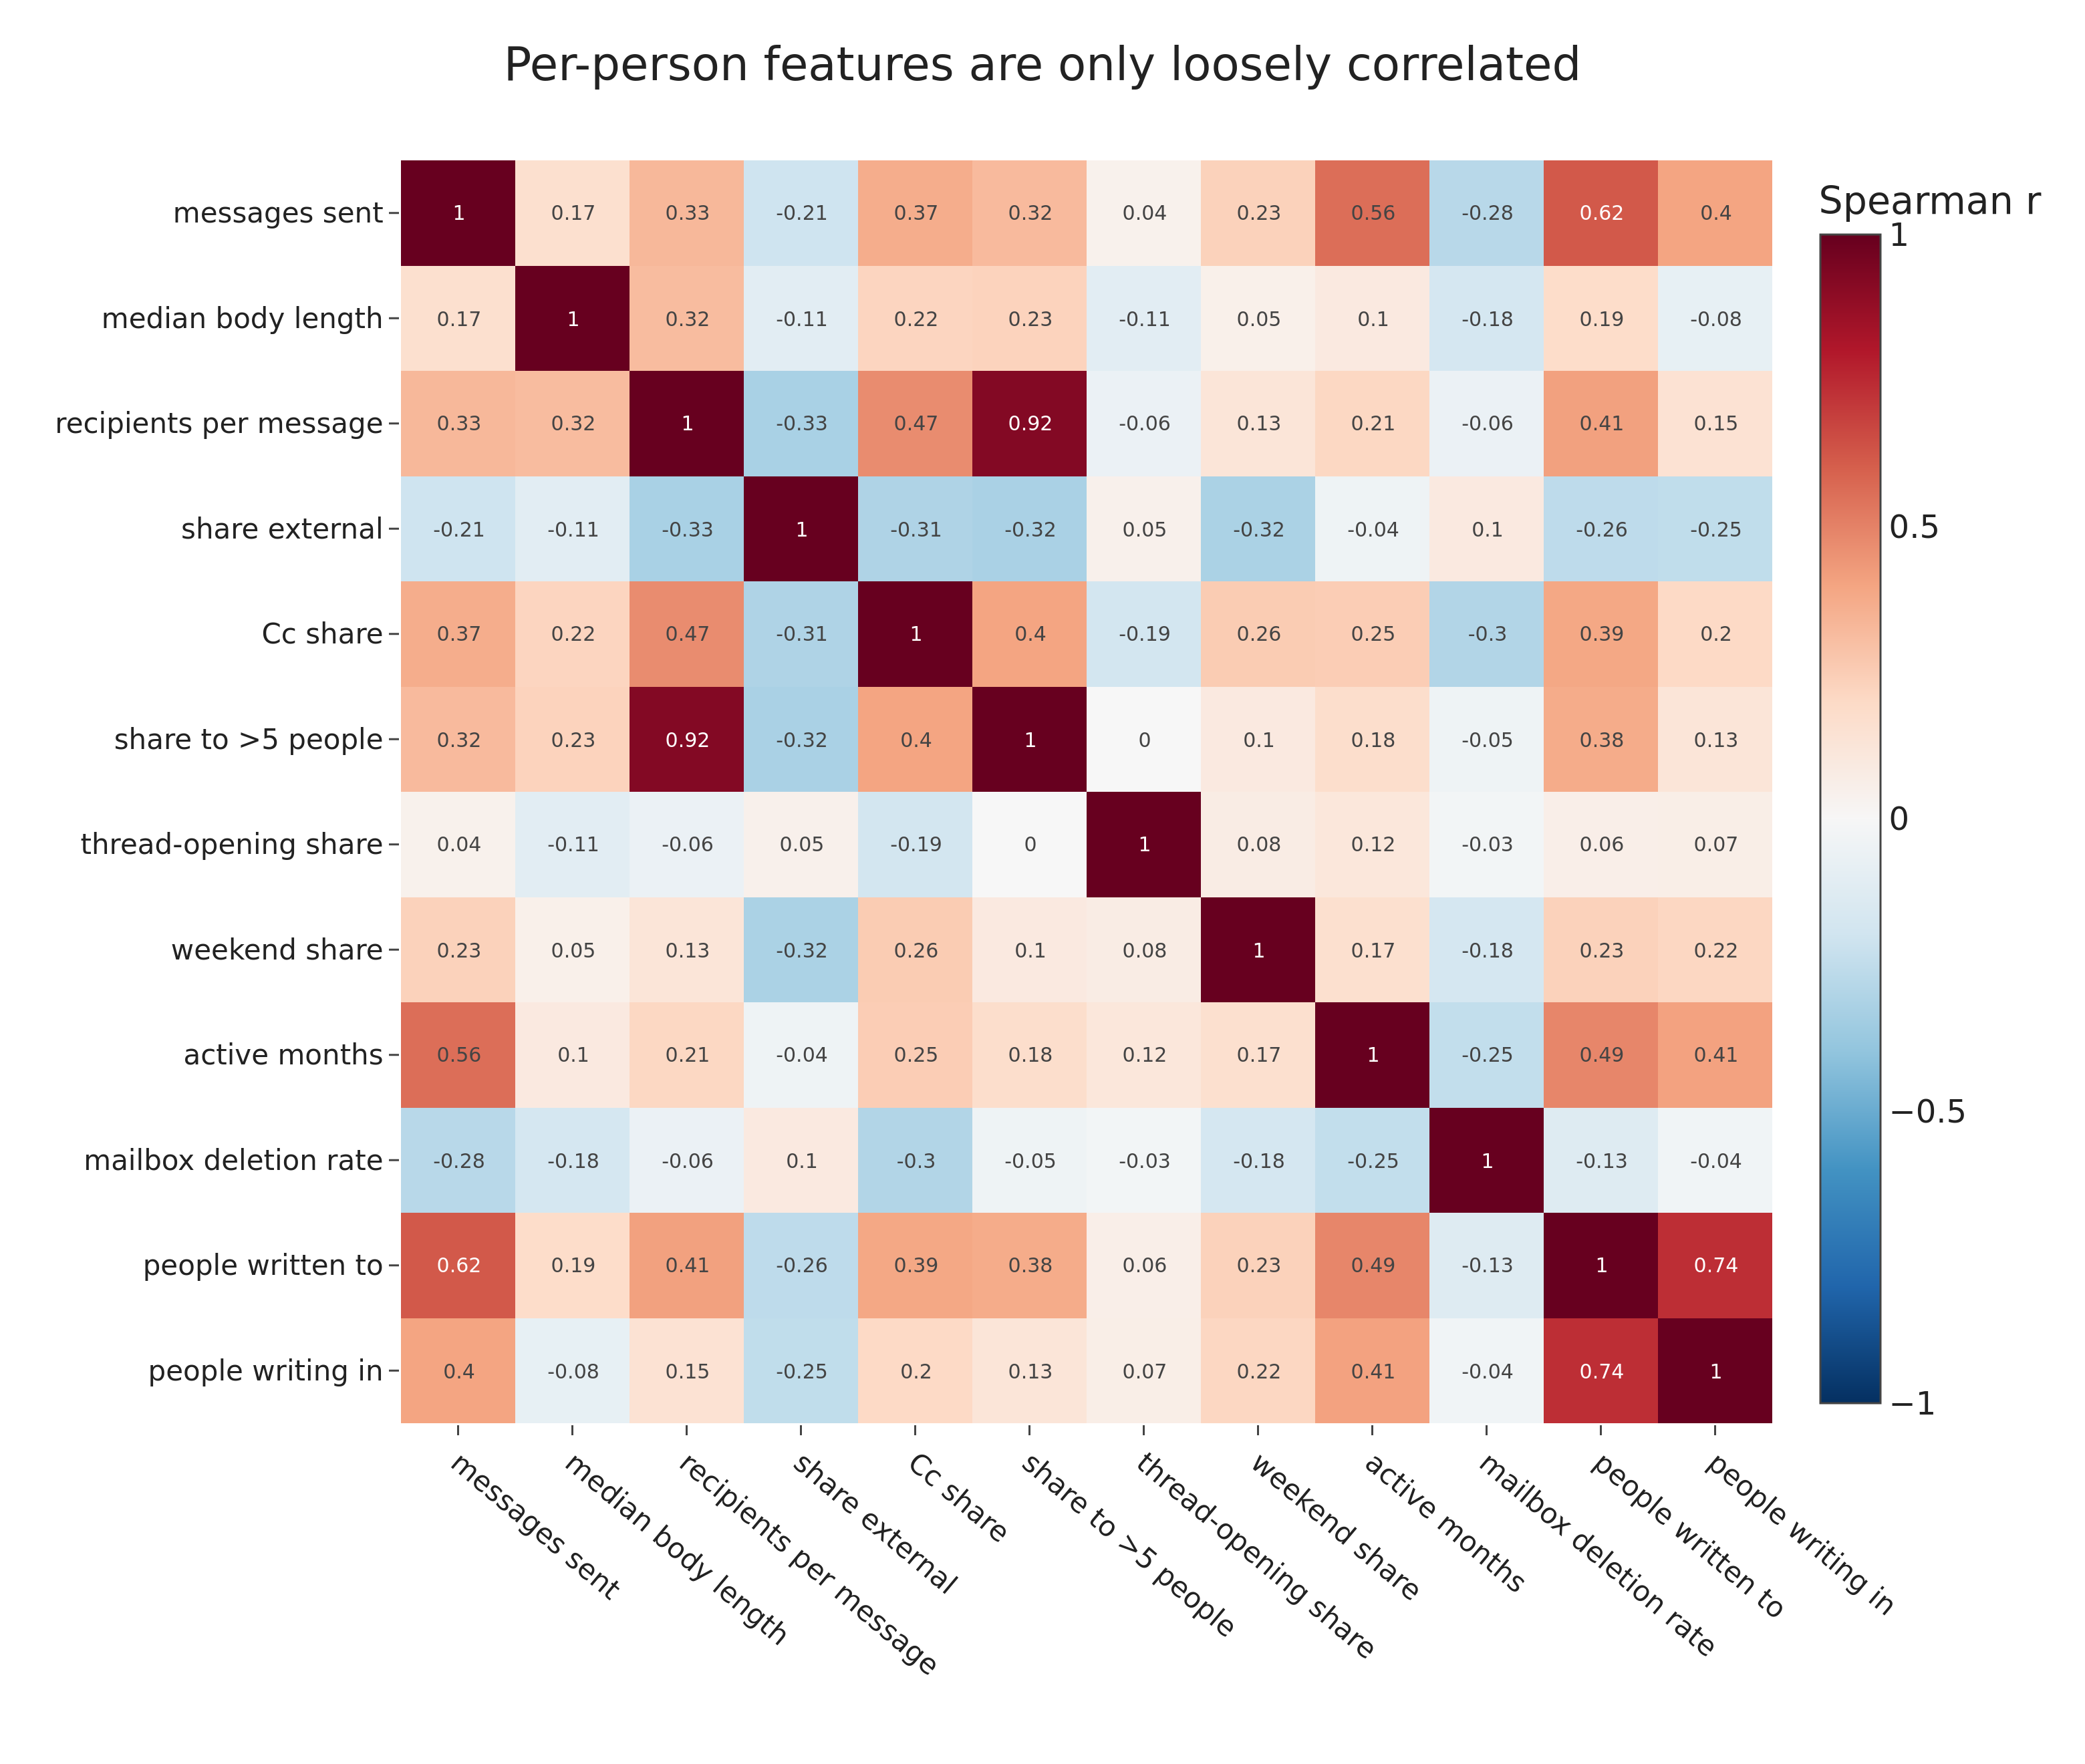

In [3]:
corr = Fraw.rename(columns=PRETTY).corr(method="spearman")
labels = list(corr.columns)
fig = go.Figure(go.Heatmap(
    z=corr.values, x=labels, y=labels, zmin=-1, zmax=1,
    colorscale="RdBu", reversescale=True, zmid=0,
    colorbar=dict(title="Spearman r"),
    text=np.round(corr.values, 2), texttemplate="%{text}", textfont=dict(size=10)))
fig.update_layout(title="Per-person features are only loosely correlated")
fig.update_xaxes(tickangle=40); fig.update_yaxes(autorange="reversed")
save_fig(fig, "p1_feature_correlation.png", w=1040, h=880,
         margin=dict(l=200, r=80, t=80, b=170))

## How many groups

We cluster with Ward's method (the same linkage that draws the dendrogram below)
and read the number of groups off two diagnostics: the average silhouette, which
rewards tight, well-separated clusters, and the within-cluster spread, whose
elbow marks where extra clusters stop buying much. The silhouette peaks at
**three** groups (about 0.18) and falls if we force a fourth, so we cut the tree
at three. Even the peak is modest, which is the honest summary for social
behaviour: people sit on a gradient with a couple of distinctive corners rather
than three cleanly separated islands, so we treat the groups as descriptive
roles, not hard boxes. As the dendrogram shows, the large third group is itself
a gradient that splits further if pushed, but those sub-splits are not
well-separated enough to stand on their own.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


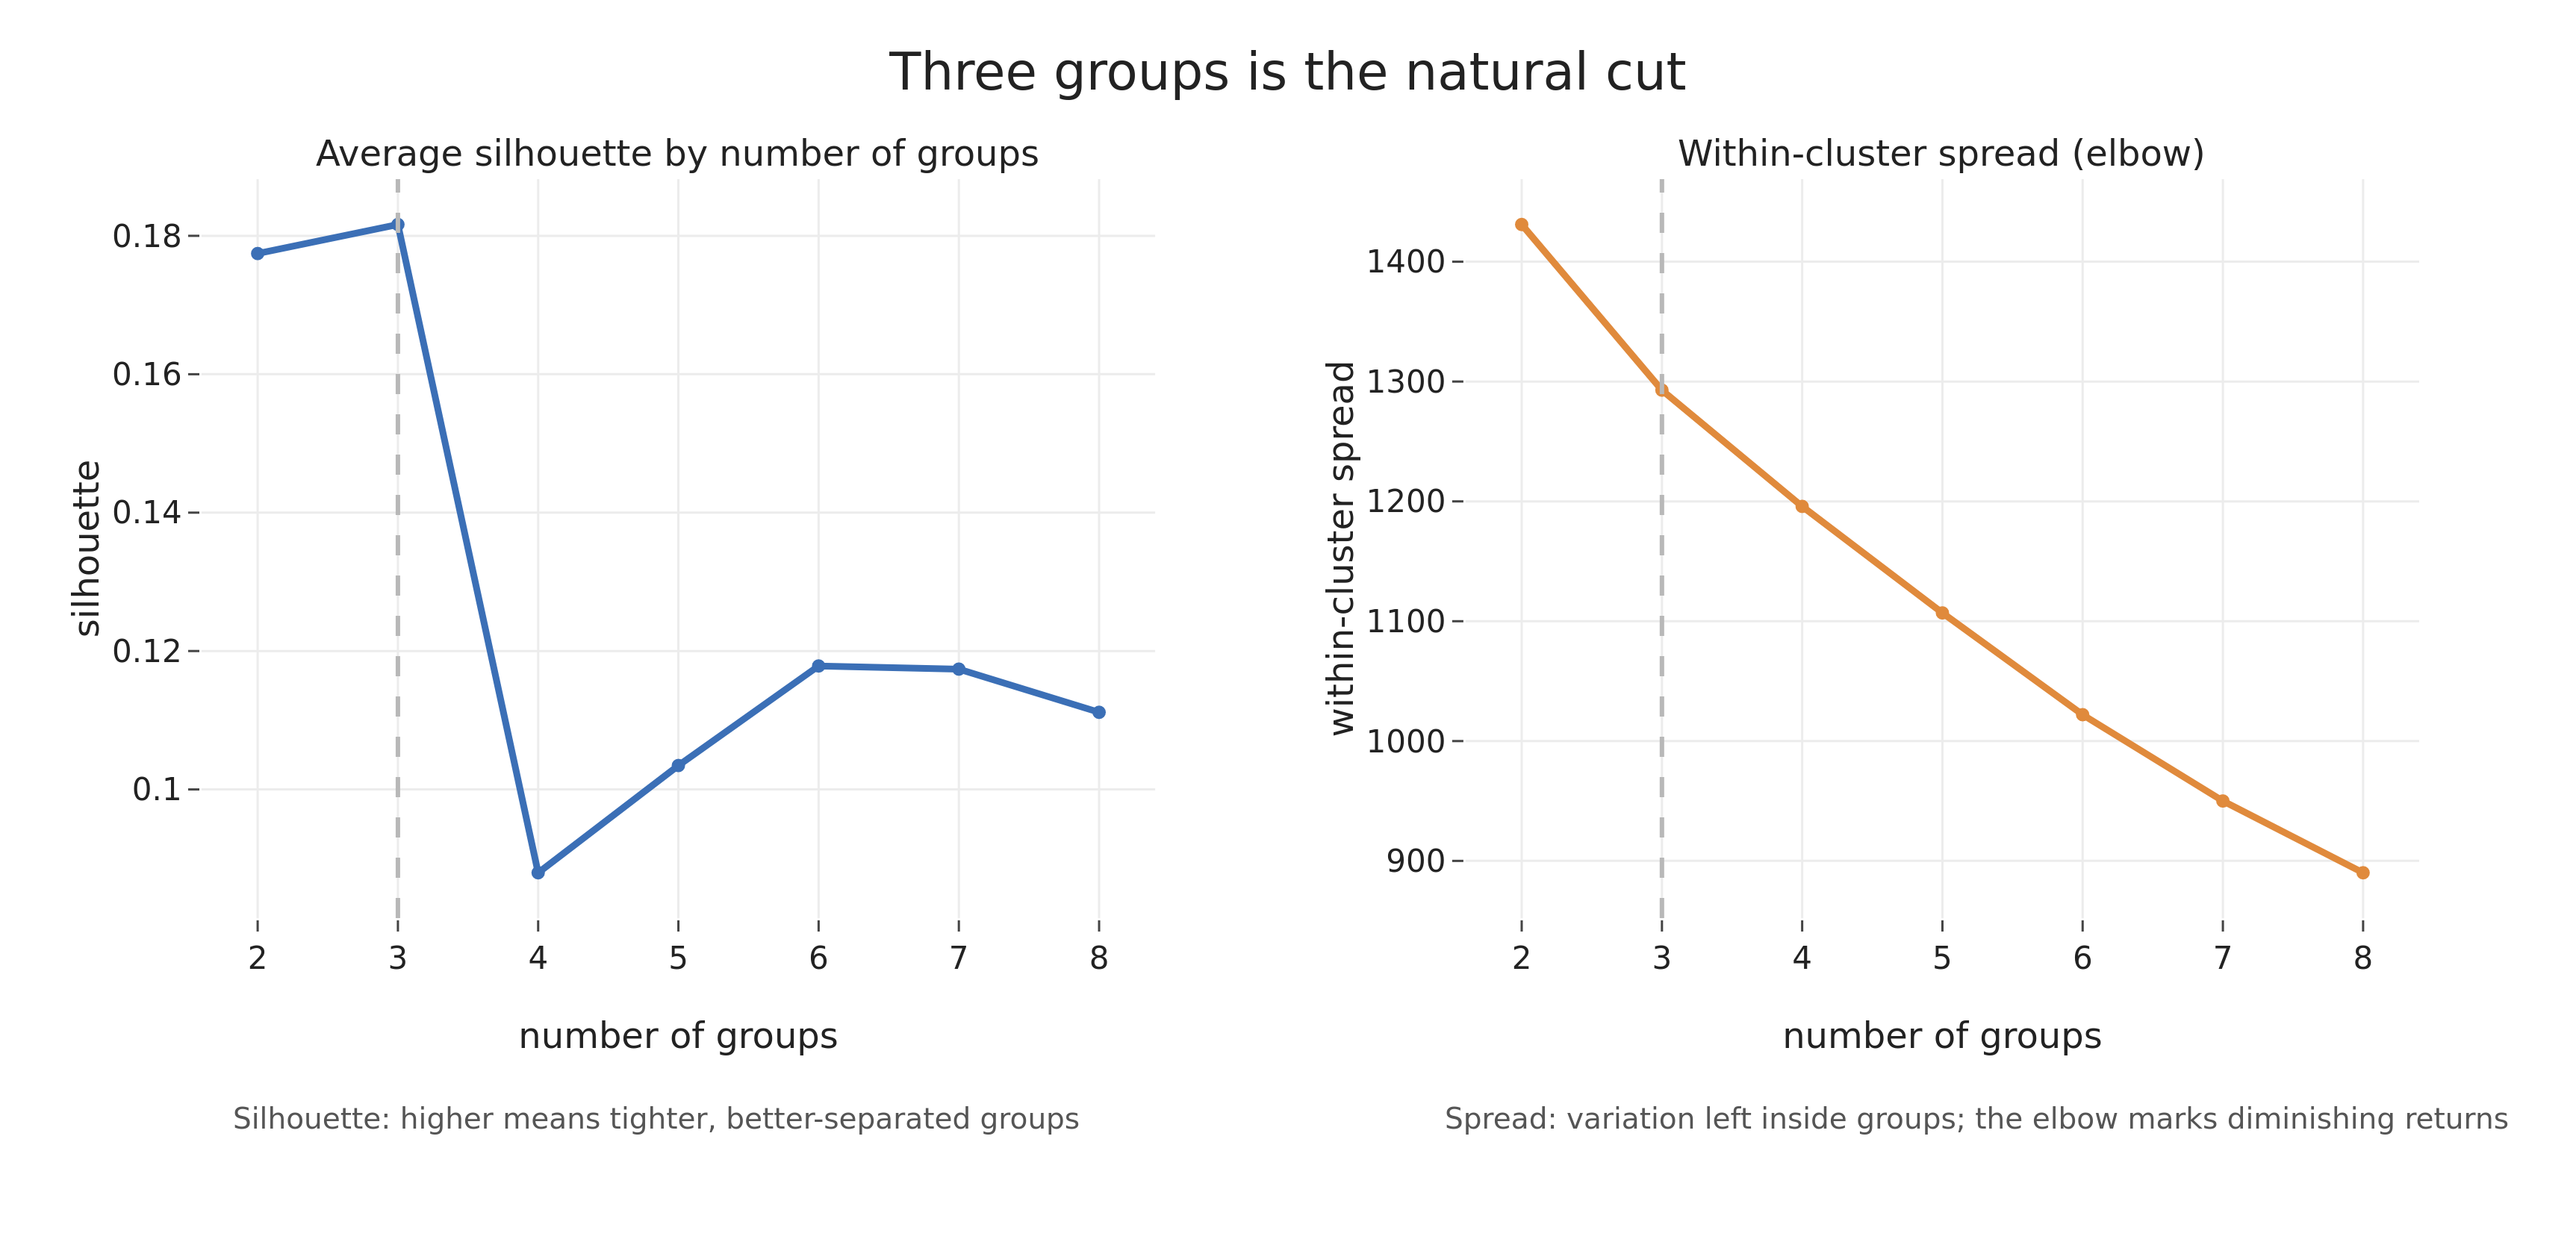

{'Outward-facing': 50, 'Broadcasters / execs': 8, 'Internal majority': 85}

Outward-facing (n=50): Arora H, Badeer R, Brawner S, Carson M, Cuilla M, Davis D, Dean C, Donohoe T, Dorland C, Ermis F, Fischer M, Gang L, Giron D, Guzman M ...

Broadcasters / execs (n=8): Bailey S, Baughman D, Hain M, Lay K, Panus S, Skilling J, Whalley L, Williams W3

Internal majority (n=85): Allen P, Arnold J, Bass E, Beck S, Blair L, Buy R, Campbell L, Cash M, Causholli M, Corman S, Crandell S, Dasovich J, Delainey D, Derrick J ...


In [4]:
Z = linkage(X, method="ward")
ks = list(range(2, 9))
sils, inertias = [], []
for k in ks:
    lab = fcluster(Z, k, criterion="maxclust")
    sils.append(silhouette_score(X, lab) if k > 1 else np.nan)
    # within-cluster sum of squares for the Ward cut
    wss = 0.0
    for c in np.unique(lab):
        pts = X[lab == c]
        wss += ((pts - pts.mean(0)) ** 2).sum()
    inertias.append(wss)

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.14,
    subplot_titles=["Average silhouette by number of groups",
                    "Within-cluster spread (elbow)"])
fig.add_trace(go.Scatter(x=ks, y=sils, mode="lines+markers", marker_color=BLUE,
    line=dict(width=3), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=ks, y=inertias, mode="lines+markers", marker_color=ORANGE,
    line=dict(width=3), showlegend=False), row=1, col=2)
for c in (1, 2):
    fig.add_vline(x=3, line=dict(color=GREY, dash="dash"), row=1, col=c)
fig.update_xaxes(title_text="number of groups", dtick=1)
fig.update_yaxes(title_text="silhouette", row=1, col=1)
fig.update_yaxes(title_text="within-cluster spread", row=1, col=2)
fig.add_annotation(text="Silhouette: higher means tighter, better-separated groups",
    xref="paper", yref="paper", x=0.205, y=-0.30, showarrow=False, xanchor="center",
    font=dict(size=13, color="#555555"))
fig.add_annotation(text="Spread: variation left inside groups; the elbow marks diminishing returns",
    xref="paper", yref="paper", x=0.80, y=-0.30, showarrow=False, xanchor="center",
    font=dict(size=13, color="#555555"))
fig.update_layout(title="Three groups is the natural cut")
save_fig(fig, "p2_k_selection.png", w=1150, h=560,
         margin=dict(l=90, r=70, t=80, b=150))

K = 3
clabel = fcluster(Z, K, criterion="maxclust")
Fraw["cluster"] = clabel
prof = Fraw.groupby("cluster")[list(PRETTY)].mean()

# name clusters by their defining feature, robust to label order
names, used = {}, set()
ex = prof["broadcast"].idxmax(); names[ex] = "Broadcasters / execs"; used.add(ex)
out = prof.loc[~prof.index.isin(used), "ext_ratio"].idxmax(); names[out] = "Outward-facing"; used.add(out)
maj = [c for c in prof.index if c not in used][0]; names[maj] = "Internal majority"
CMAP = {"Broadcasters / execs": RED, "Outward-facing": ORANGE,
        "Internal majority": BLUE}
cl_name = {h: names[c] for h, c in zip(keep, clabel)}
cl_color = {h: CMAP[cl_name[h]] for h in keep}
print({names[c]: int((clabel == c).sum()) for c in sorted(prof.index)})
for c in sorted(prof.index):
    mem = [disp(h) for h in keep if clabel[keep.index(h)] == c]
    print(f"\n{names[c]} (n={len(mem)}): {', '.join(mem[:14])}{' ...' if len(mem)>14 else ''}")

## The three groups in two dimensions

A PCA projection puts the 143 people on a plane that keeps as much of the
twelve-dimensional spread as possible; the arrows show how the original features
load onto it. The first axis is essentially *volume and reach* - heavy senders
with wide degree to one side - and the second separates *outward, external*
communication from *internal* traffic. The groups sit where their names say they
should: the broadcasters/executives reach far out along the reach axis, the
outward-facing group lifts along the external axis, and the large internal
majority fills the middle. The split is a gradient, not a gap, which is exactly
what the modest silhouette said. A few named people are labelled for orientation.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


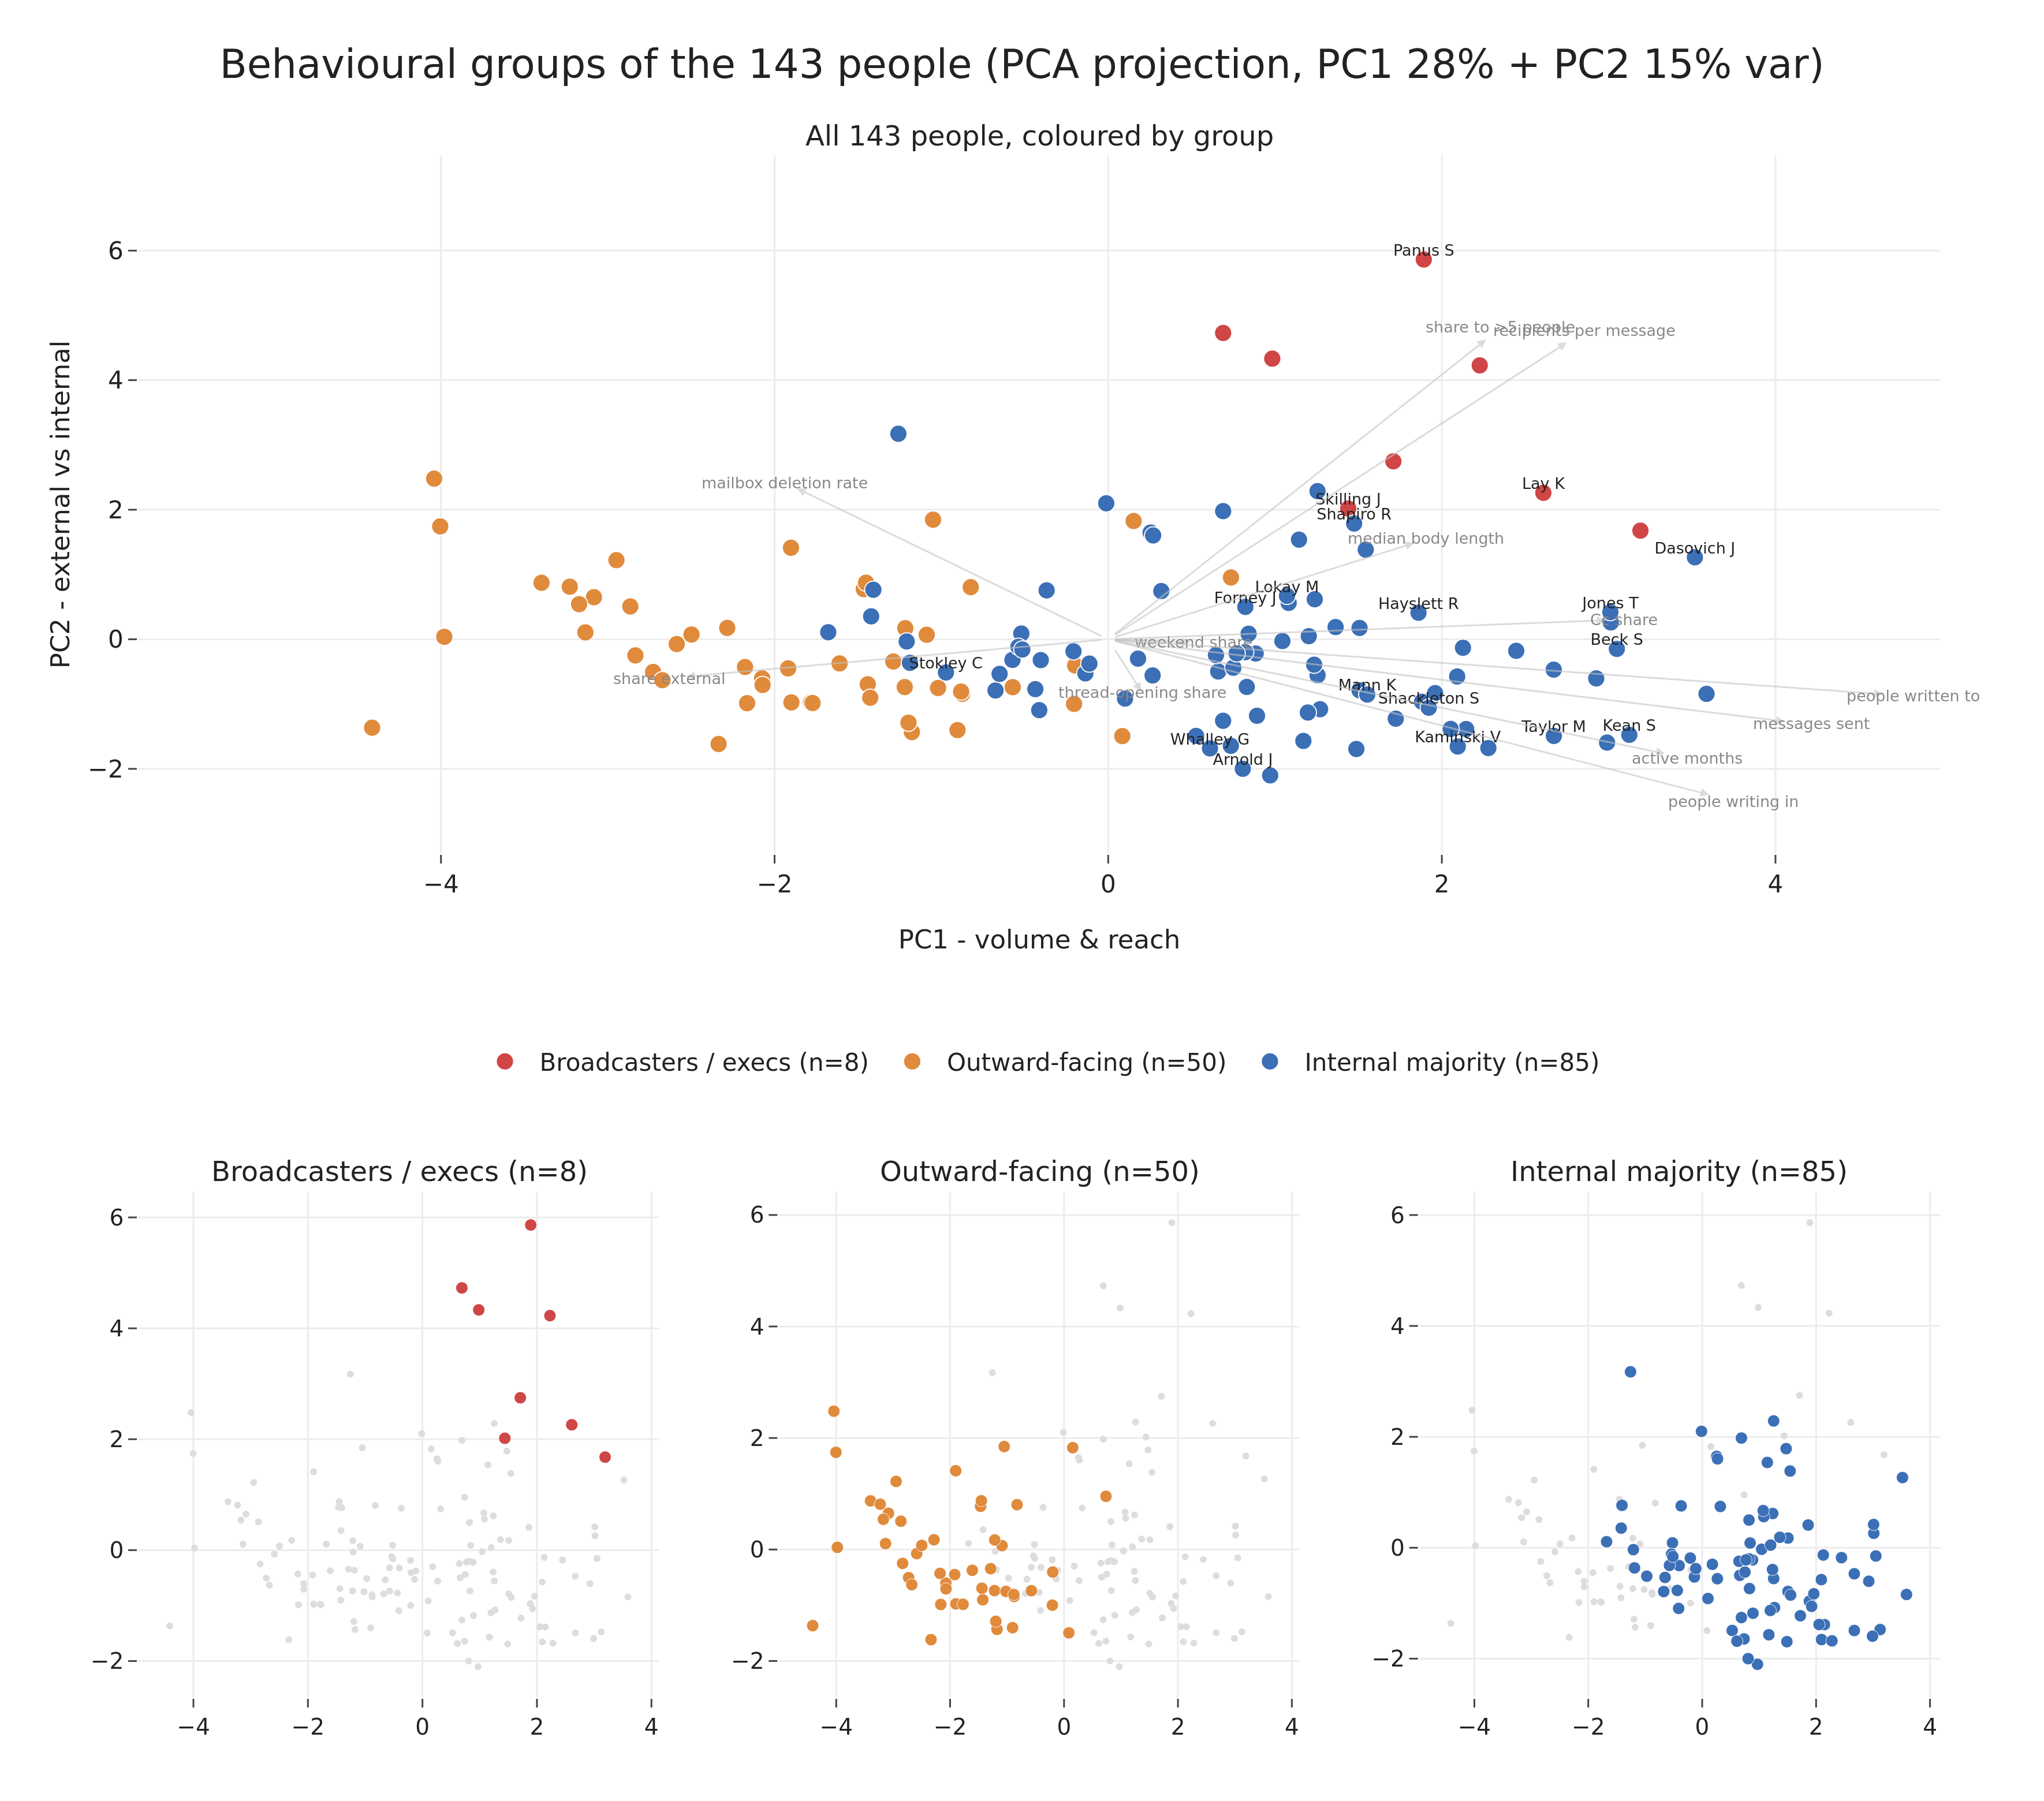

In [5]:
pca = PCA(2, random_state=0).fit(X)
XY = pca.transform(X)
ev = pca.explained_variance_ratio_
NOTABLE = ["lay-k","skilling-j","whalley-g","kaminski-v","dasovich-j","kean-s",
           "shapiro-r","jones-t","taylor-m","shackleton-s","forney-j","mann-k",
           "beck-s","arnold-j","lokay-m","hayslett-r","stokley-c","panus-s"]
order = ["Broadcasters / execs", "Outward-facing", "Internal majority"]
gsize = {nm: sum(cl_name[h] == nm for h in keep) for nm in order}

fig = make_subplots(rows=2, cols=3, row_heights=[0.58, 0.42], vertical_spacing=0.22,
    specs=[[{"colspan": 3}, None, None], [{}, {}, {}]],
    subplot_titles=["All 143 people, coloured by group",
                    *[f"{nm} (n={gsize[nm]})" for nm in order]])

# row 1: every group together
for nm in order:
    idx = [i for i, h in enumerate(keep) if cl_name[h] == nm]
    fig.add_trace(go.Scatter(
        x=XY[idx, 0], y=XY[idx, 1], mode="markers", name=f"{nm} (n={len(idx)})",
        marker=dict(size=10, color=CMAP[nm], line=dict(width=0.6, color="white")),
        text=[disp(keep[i]) for i in idx], hoverinfo="text+name"), row=1, col=1)
lab_idx = [i for i, h in enumerate(keep) if h in NOTABLE]
fig.add_trace(go.Scatter(x=XY[lab_idx, 0], y=XY[lab_idx, 1], mode="text",
    text=[disp(keep[i]) for i in lab_idx], textposition="top center",
    textfont=dict(size=9, color="#222222"), showlegend=False), row=1, col=1)

# feature-loading arrows pushed out to the frame so they only indicate direction
# and do not sit on top of the points; labels land in the outer margin
xr = [XY[:, 0].min() - 1.4, XY[:, 0].max() + 1.4]
yr = [XY[:, 1].min() - 1.2, XY[:, 1].max() + 1.6]
sx = (xr[1] - xr[0]) / 2 * 0.86 / np.abs(pca.components_[0]).max()
sy = (yr[1] - yr[0]) / 2 * 0.86 / np.abs(pca.components_[1]).max()
for j, f in enumerate(PRETTY):
    tx, ty = pca.components_[0, j] * sx, pca.components_[1, j] * sy
    fig.add_annotation(x=tx, y=ty, ax=0, ay=0, xref="x", yref="y", axref="x",
        ayref="y", showarrow=True, arrowhead=2, arrowwidth=1.0,
        arrowcolor="#c4c4c4", opacity=0.6)
    fig.add_annotation(x=tx * 1.04, y=ty * 1.04, text=PRETTY[f], showarrow=False,
        font=dict(size=9, color="#888888"))

# row 2: one panel per group, lit on a grey backdrop of everyone
for k, nm in enumerate(order):
    c = k + 1
    fig.add_trace(go.Scatter(x=XY[:, 0], y=XY[:, 1], mode="markers",
        marker=dict(size=4, color="#dddddd"), showlegend=False, hoverinfo="skip"),
        row=2, col=c)
    idx = [i for i, h in enumerate(keep) if cl_name[h] == nm]
    fig.add_trace(go.Scatter(x=XY[idx, 0], y=XY[idx, 1], mode="markers",
        marker=dict(size=7, color=CMAP[nm], line=dict(width=0.3, color="white")),
        showlegend=False, hoverinfo="skip"), row=2, col=c)

fig.update_layout(
    title=f"Behavioural groups of the 143 people (PCA projection, "
          f"PC1 {ev[0]:.0%} + PC2 {ev[1]:.0%} var)",
    legend=dict(orientation="h", y=0.43, x=0.5, xanchor="center", font=dict(size=14)))
fig.update_xaxes(title_text="PC1 - volume & reach", title_font=dict(size=15),
                 range=xr, row=1, col=1)
fig.update_yaxes(title_text="PC2 - external vs internal", title_font=dict(size=15),
                 range=yr, row=1, col=1)
for c in (1, 2, 3):
    fig.update_xaxes(tickfont=dict(size=13), row=2, col=c)
    fig.update_yaxes(tickfont=dict(size=13), row=2, col=c)
save_fig(fig, "p3_pca_clusters.png", w=1180, h=1040,
         margin=dict(l=80, r=60, t=90, b=60))

## The hierarchy behind the cut

The dendrogram merges the two most similar people, then the two most similar
groups, all the way up, so the height at which two branches join is how different
they are. With 143 people the full tree is unreadable, so we show its top,
grouped down to twelve cluster-leaves, each labelled with how many people it
holds. The shape is the point: a couple of small tight branches separate at a
large height while the bulk of the company merges late into one internal mass,
which is exactly why the silhouette favours a small number of groups. The dashed
line is the three-group cut, and each branch is labelled with its group name and
size. Because the tree is grouped to twelve leaves it shows cluster blocks rather
than named individuals; how individual people differ from one another is taken up
separately at the end.

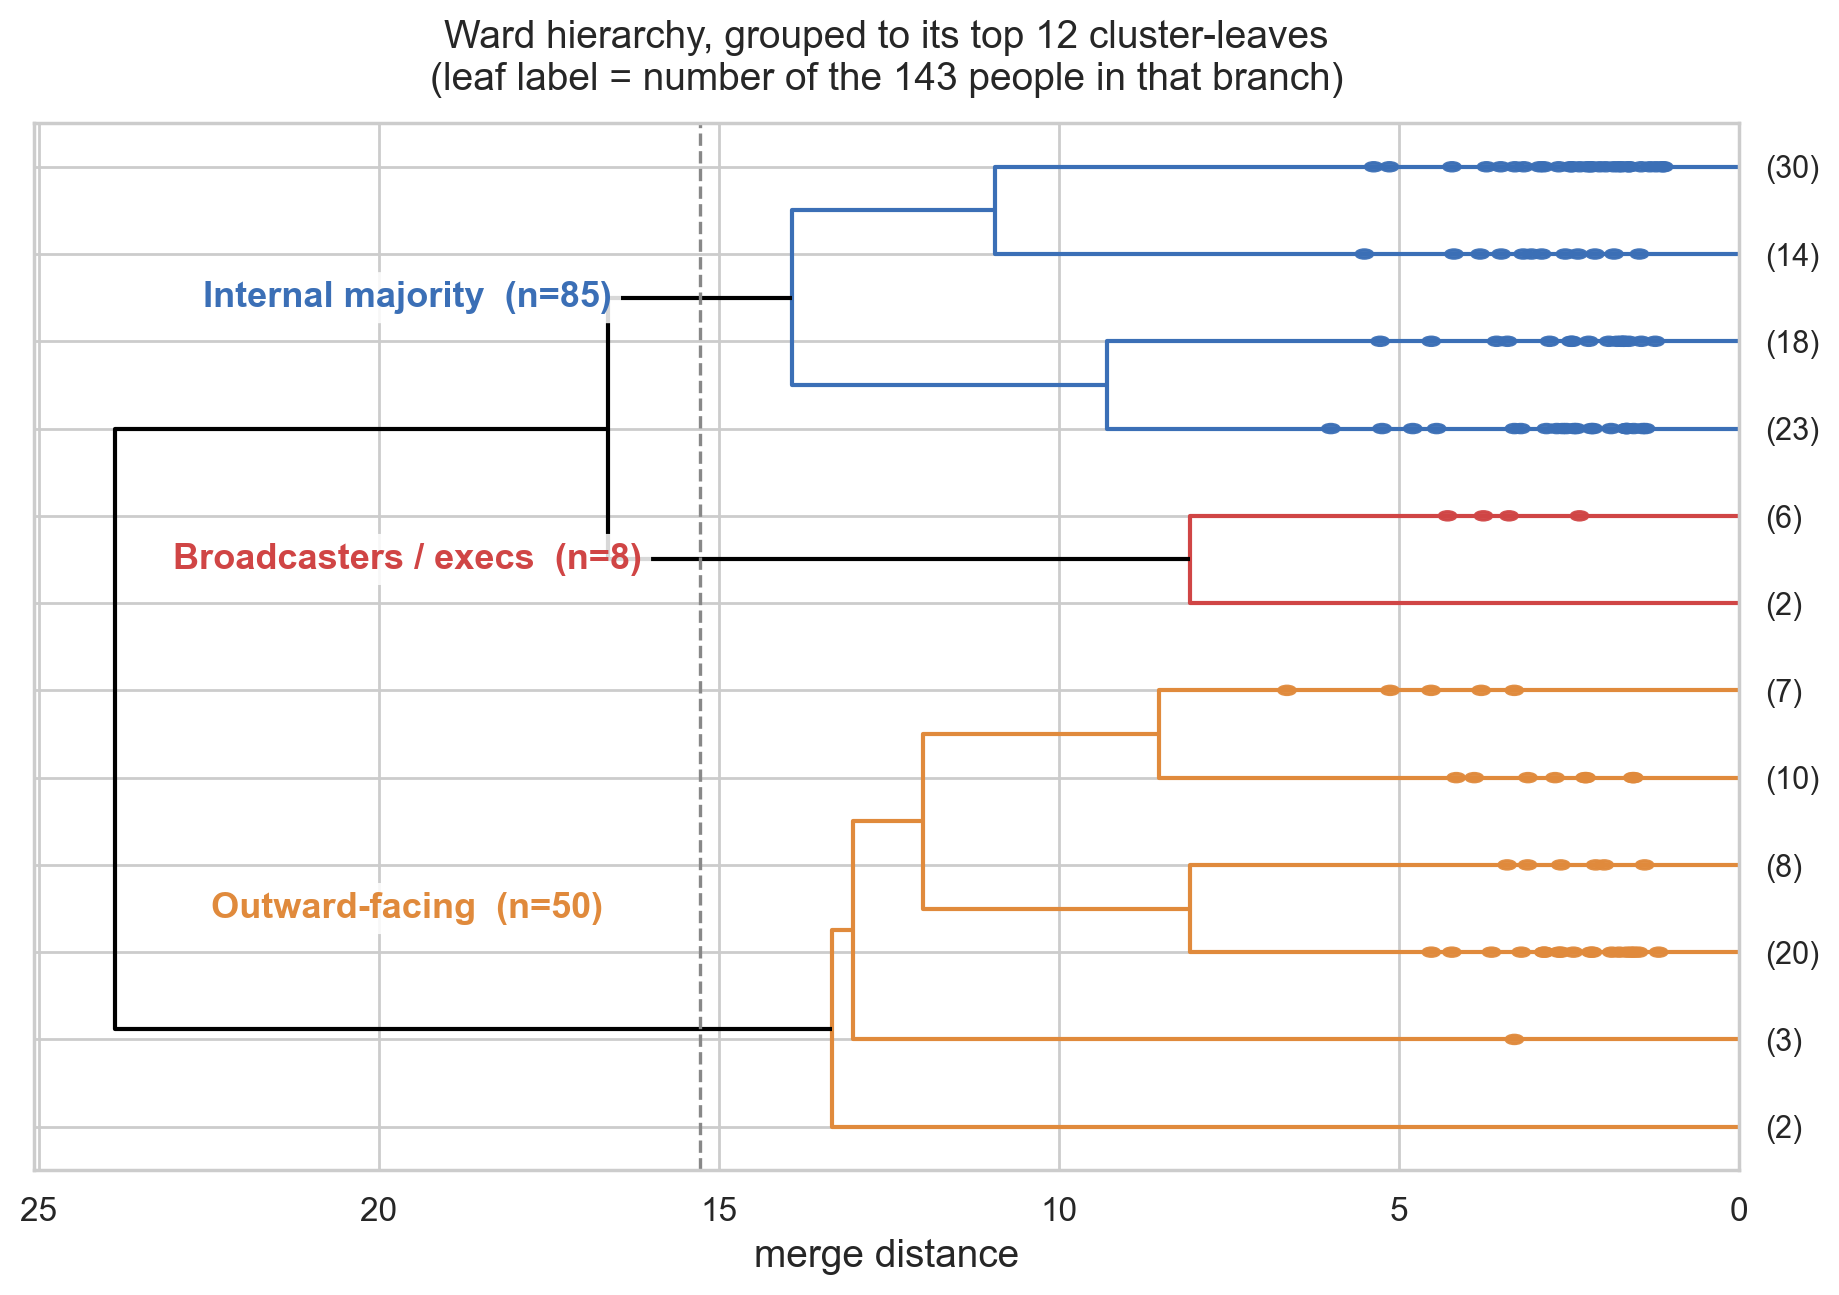

In [6]:
P = 12  # group the tree down to its top cluster-leaves so it stays readable
ct = 0.5 * (Z[-(K-1), 2] + Z[-K, 2])
n = len(keep)

# the behavioural group of each linkage node, or None if it spans more than one
node_group = {}
def _grp(nid):
    if nid < n:
        node_group[nid] = int(clabel[nid]); return {node_group[nid]}
    s = _grp(int(Z[nid - n, 0])) | _grp(int(Z[nid - n, 1]))
    node_group[nid] = (next(iter(s)) if len(s) == 1 else None)
    return s
_grp(2 * n - 2)
def link_color(nid):
    g = node_group.get(nid)
    return CMAP[names[g]] if g is not None else "black"   # group-joining links in black

fig, ax = plt.subplots(figsize=(11, 6.8))
dendrogram(Z, orientation="left", truncate_mode="lastp", p=P,
           link_color_func=link_color, show_contracted=True,
           leaf_font_size=11, ax=ax)
ax.axvline(ct, color="#888888", ls="--", lw=1.2)

# leaf position -> behavioural group, so labels and dots can be coloured
lab12 = fcluster(Z, P, "maxclust")
c12g = {int(lab12[i]): int(clabel[i]) for i in range(n)}
seq = []
for idx in dendrogram(Z, no_plot=True)["leaves"]:
    c = int(lab12[idx])
    if not seq or seq[-1] != c:
        seq.append(c)
leafy_group = {10 * j + 5: c12g[seq[j]] for j in range(len(seq))}

# recolour the contracted-cluster dots (scipy draws them as black ellipses) to
# match the group of the leaf line they sit on
for e in list(ax.patches):
    if type(e).__name__ == "Ellipse":
        j = max(0, min(len(seq) - 1, int(round((e.center[1] - 5) / 10))))
        col = CMAP[names[c12g[seq[j]]]]
        e.set_facecolor(col); e.set_edgecolor(col); e.set_alpha(0.95)

# name each of the three branches, placed well to the left in the open area
hmax = float(Z[:, 2].max())
label_x = ct + 0.50 * (hmax - ct)
yc = {}
for j, c in enumerate(seq):
    yc.setdefault(c12g[c], []).append(10 * j + 5)
for gid, yl in yc.items():
    ax.text(label_x, float(np.mean(yl)),
            f"{names[gid]}  (n={int((clabel == gid).sum())})",
            color=CMAP[names[gid]], fontsize=13, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))
ax.set_title(f"Ward hierarchy, grouped to its top {P} cluster-leaves\n"
             "(leaf label = number of the 143 people in that branch)",
             fontsize=14, pad=12)
ax.set_xlabel("merge distance")
save_mpl(fig, "p4_dendrogram.png", dpi=200)

## What defines each group

The heatmap reads each group against the average person: cells are the group
mean of every feature in standard deviations from the overall mean, red above,
blue below. The picture is clean. The **broadcasters / execs** send to many
people at once with long messages and wide out-degree - announcement and
direction-setting traffic - and this is the group holding Lay, Skilling and a
Whalley desk. The **outward-facing** group is defined by external mail: a large
share of what they send leaves Enron, the signature of deal-makers and
counterparty contacts, on a lighter internal footprint. The **internal
majority** is everyone else: internal-facing, Cc-heavy, the densest internal
degree and the steadiest volume - the engine room of the company. The
differences are between *roles*, not departments.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


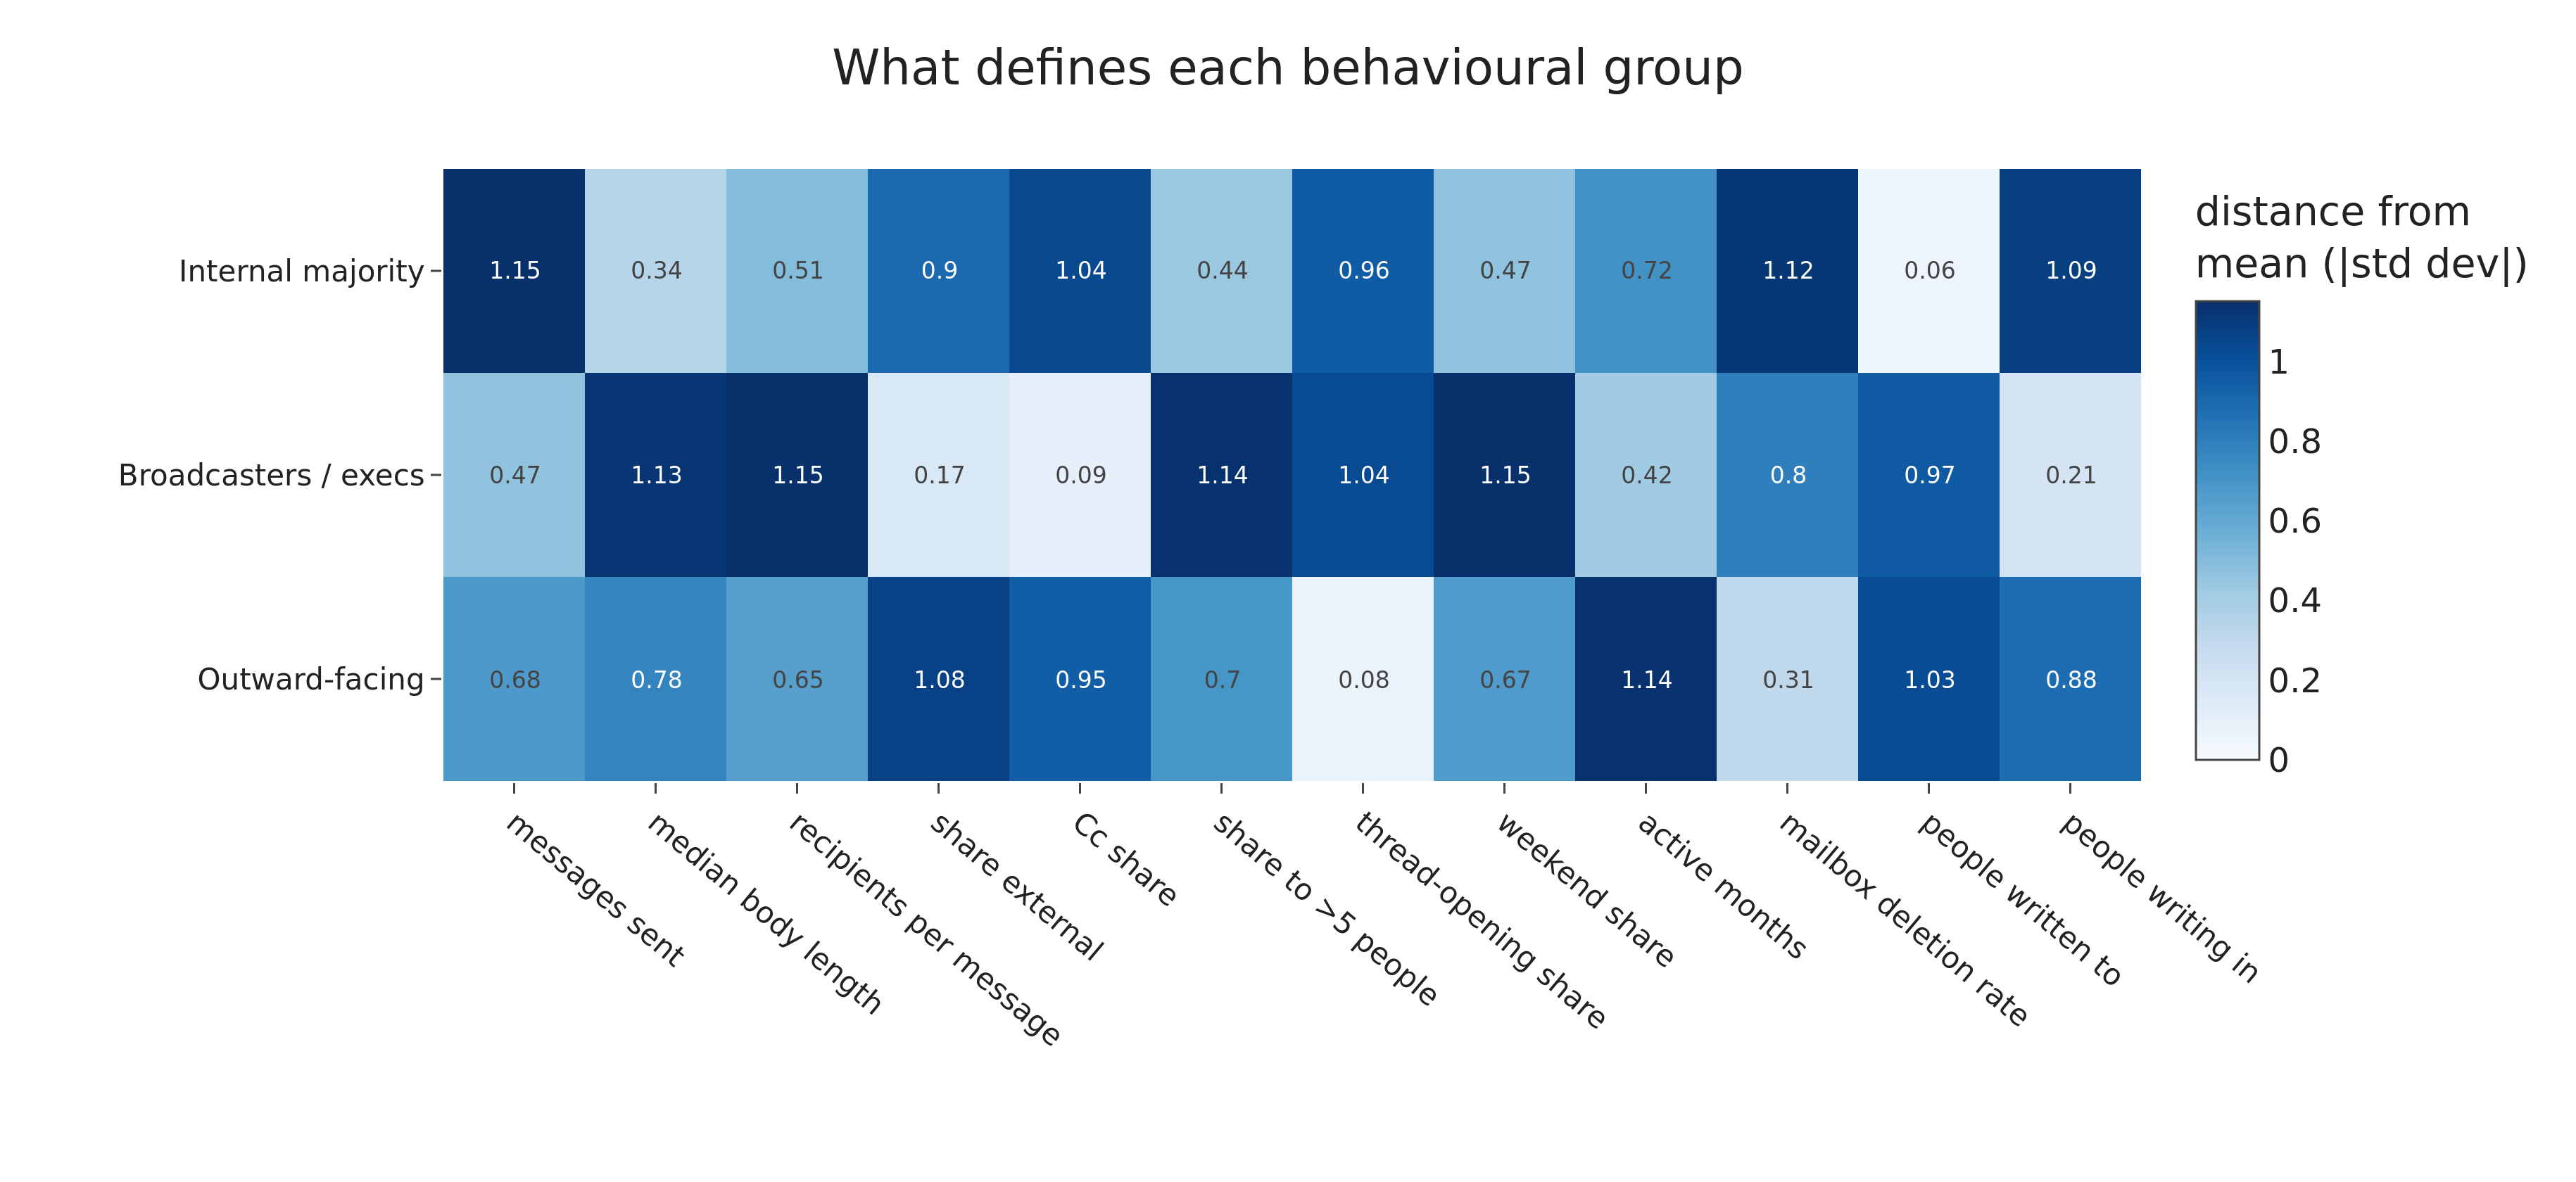

In [7]:
zprof = (prof - prof.mean()) / prof.std()
zprof = zprof.loc[[c for c in prof.index]]
row_names = [names[c] for c in zprof.index]
# colour by distance from the average (magnitude), so the single hue is not
# misread as a sign; the printed number keeps the +/- direction
fig = go.Figure(go.Heatmap(
    z=np.abs(zprof.values), x=[PRETTY[c] for c in zprof.columns], y=row_names,
    colorscale="Blues", zmin=0, zmax=float(np.abs(zprof.values).max()),
    colorbar=dict(title="distance from<br>mean (|std dev|)"),
    text=np.round(np.abs(zprof.values), 2), texttemplate="%{text}", textfont=dict(size=11)))
fig.update_layout(title="What defines each behavioural group")
fig.update_xaxes(tickangle=40)
save_fig(fig, "p5_cluster_profiles.png", w=1220, h=560,
         margin=dict(l=210, r=90, t=80, b=190))

## Behaviour cuts across the social communities

Last week a modularity split of the reciprocal people-graph found five
communities that mapped onto real parts of the company (the trading floor, the
West-power desk, ENA legal, pipelines, and the executive/government-affairs
core). Those communities are about *who talks to whom*; the three groups here are
about *how a person communicates*. The cross-tab shows they are largely
orthogonal: every social community is mostly internal-majority members, and the
broadcasters and outward-facing people are sprinkled across communities rather
than forming one. Communication role and social neighbourhood are two different
lenses on the same people.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


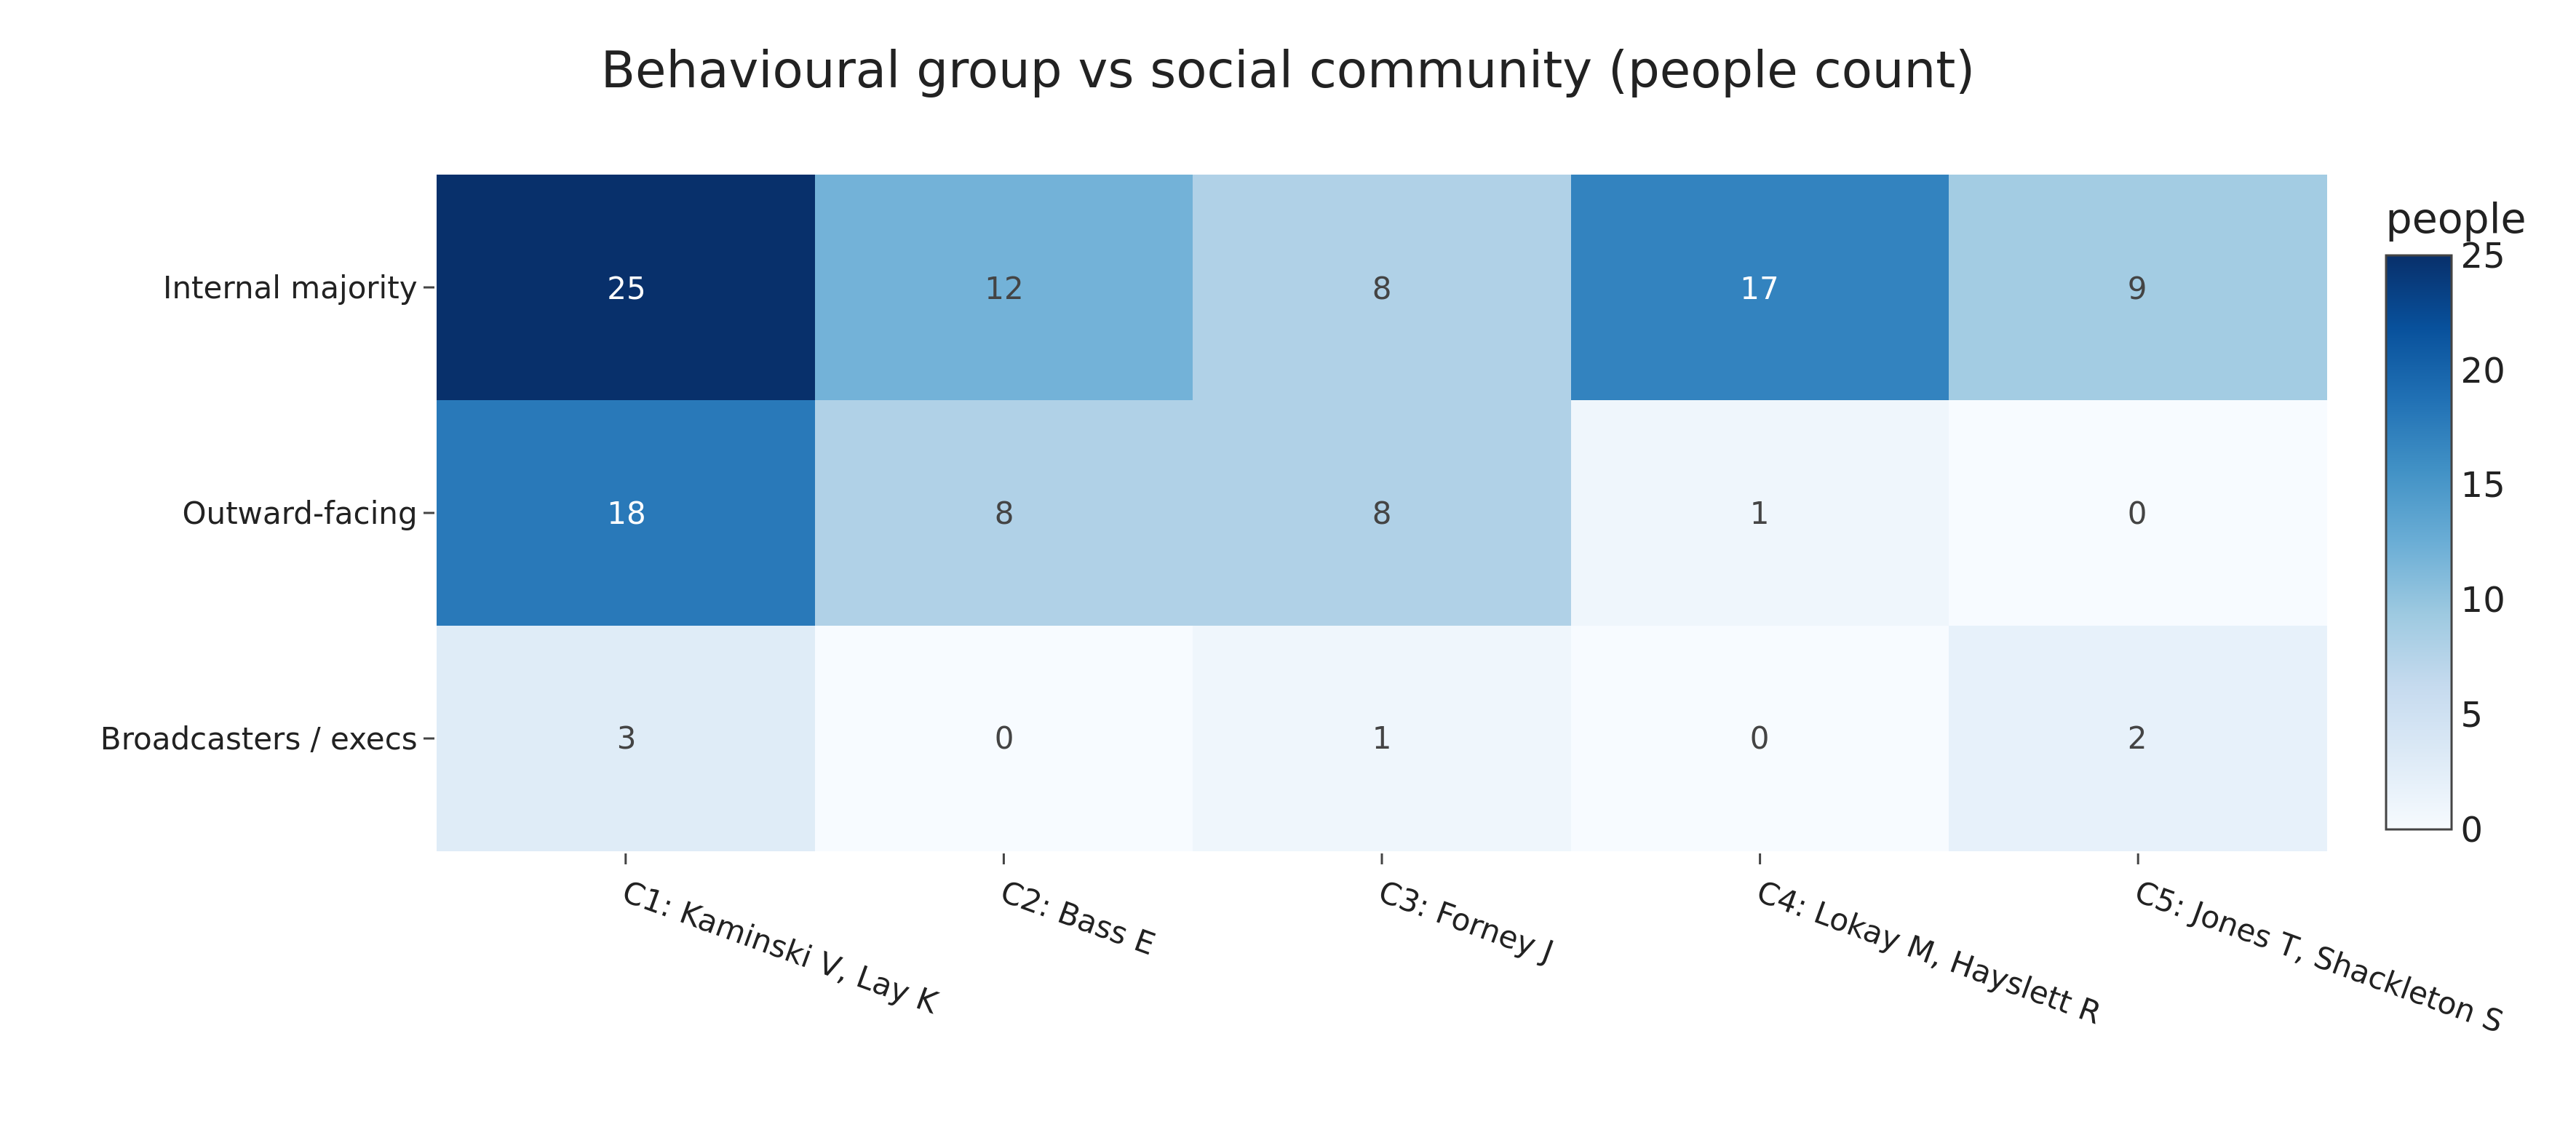

community sizes: [46, 21, 18, 18, 11]


In [8]:
import networkx as nx
ec = ei.groupby(["sender_person", "recipient_person"]).size()
eset = set(ec.index)
G = nx.Graph()
seen = set()
for (x, y), c in ec.items():
    if (y, x) in eset:
        kk = tuple(sorted((x, y)))
        if kk in seen:
            continue
        seen.add(kk)
        w = int(ec.get((kk[0], kk[1]), 0)) + int(ec.get((kk[1], kk[0]), 0))
        G.add_edge(kk[0], kk[1], weight=w)
comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
comms = sorted(comms, key=len, reverse=True)
owner_comm = {}
for i, cset in enumerate(comms):
    for o in cset:
        owner_comm[o] = i
# label each community by a couple of well-known members
def comm_label(i):
    members = [o for o in comms[i] if o in keep]
    feat = [o for o in ["dasovich-j","kaminski-v","jones-t","forney-j","lokay-m",
                        "lay-k","arnold-j","shackleton-s","hayslett-r","beck-s"] if o in comms[i]]
    tag = ", ".join(disp(x) for x in feat[:2]) if feat else disp(members[0]) if members else "-"
    return f"C{i+1}: {tag}"

rows = []
for h in keep:
    if h in owner_comm:
        rows.append((cl_name[h], owner_comm[h]))
cd = pd.DataFrame(rows, columns=["group", "comm"])
ncomm = min(5, len(comms))
ct_tab = (cd[cd["comm"] < ncomm]
          .pivot_table(index="group", columns="comm", aggfunc=len, fill_value=0))
ct_tab = ct_tab.reindex([nm for nm in CMAP if nm in ct_tab.index])
fig = go.Figure(go.Heatmap(
    z=ct_tab.values, x=[comm_label(c) for c in ct_tab.columns], y=list(ct_tab.index),
    colorscale="Blues", colorbar=dict(title="people"),
    text=ct_tab.values, texttemplate="%{text}", textfont=dict(size=14)))
fig.update_layout(title="Behavioural group vs social community (people count)")
fig.update_xaxes(tickangle=20)
save_fig(fig, "p6_group_vs_community.png", w=1180, h=520,
         margin=dict(l=200, r=90, t=80, b=130))
print("community sizes:", [len(c) for c in comms[:ncomm]])

## Do the groups line up with rank?

The clusters so far are built only from behaviour. As an external check we bring
in job titles from the Shetty-Adibi annotation of the corpus (1:1 with our 149
owners; see `eda-5/refs/`), which gives each person a status from CEO down to
Employee, with a third left unlabelled. The left panel is the title mix of each
behavioural group, the right is each group's mean seniority on a one-to-seven
scale. The alignment is real but weak. Mean rank trends the way intuition says,
broadcasters highest then the internal majority then the outward-facing group,
but the detail undercuts the tidy reading: most of the actual vice-presidents
sit in the large internal majority, not in the small broadcaster cluster, and
the outward-facing group is where the traders and lower-tenure employees
concentrate. Behaviour reflects communication role and intensity, which is
correlated with rank but is plainly not the same axis. A third of the people
carry no listed title, so this is a sanity check, not a scoreboard.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


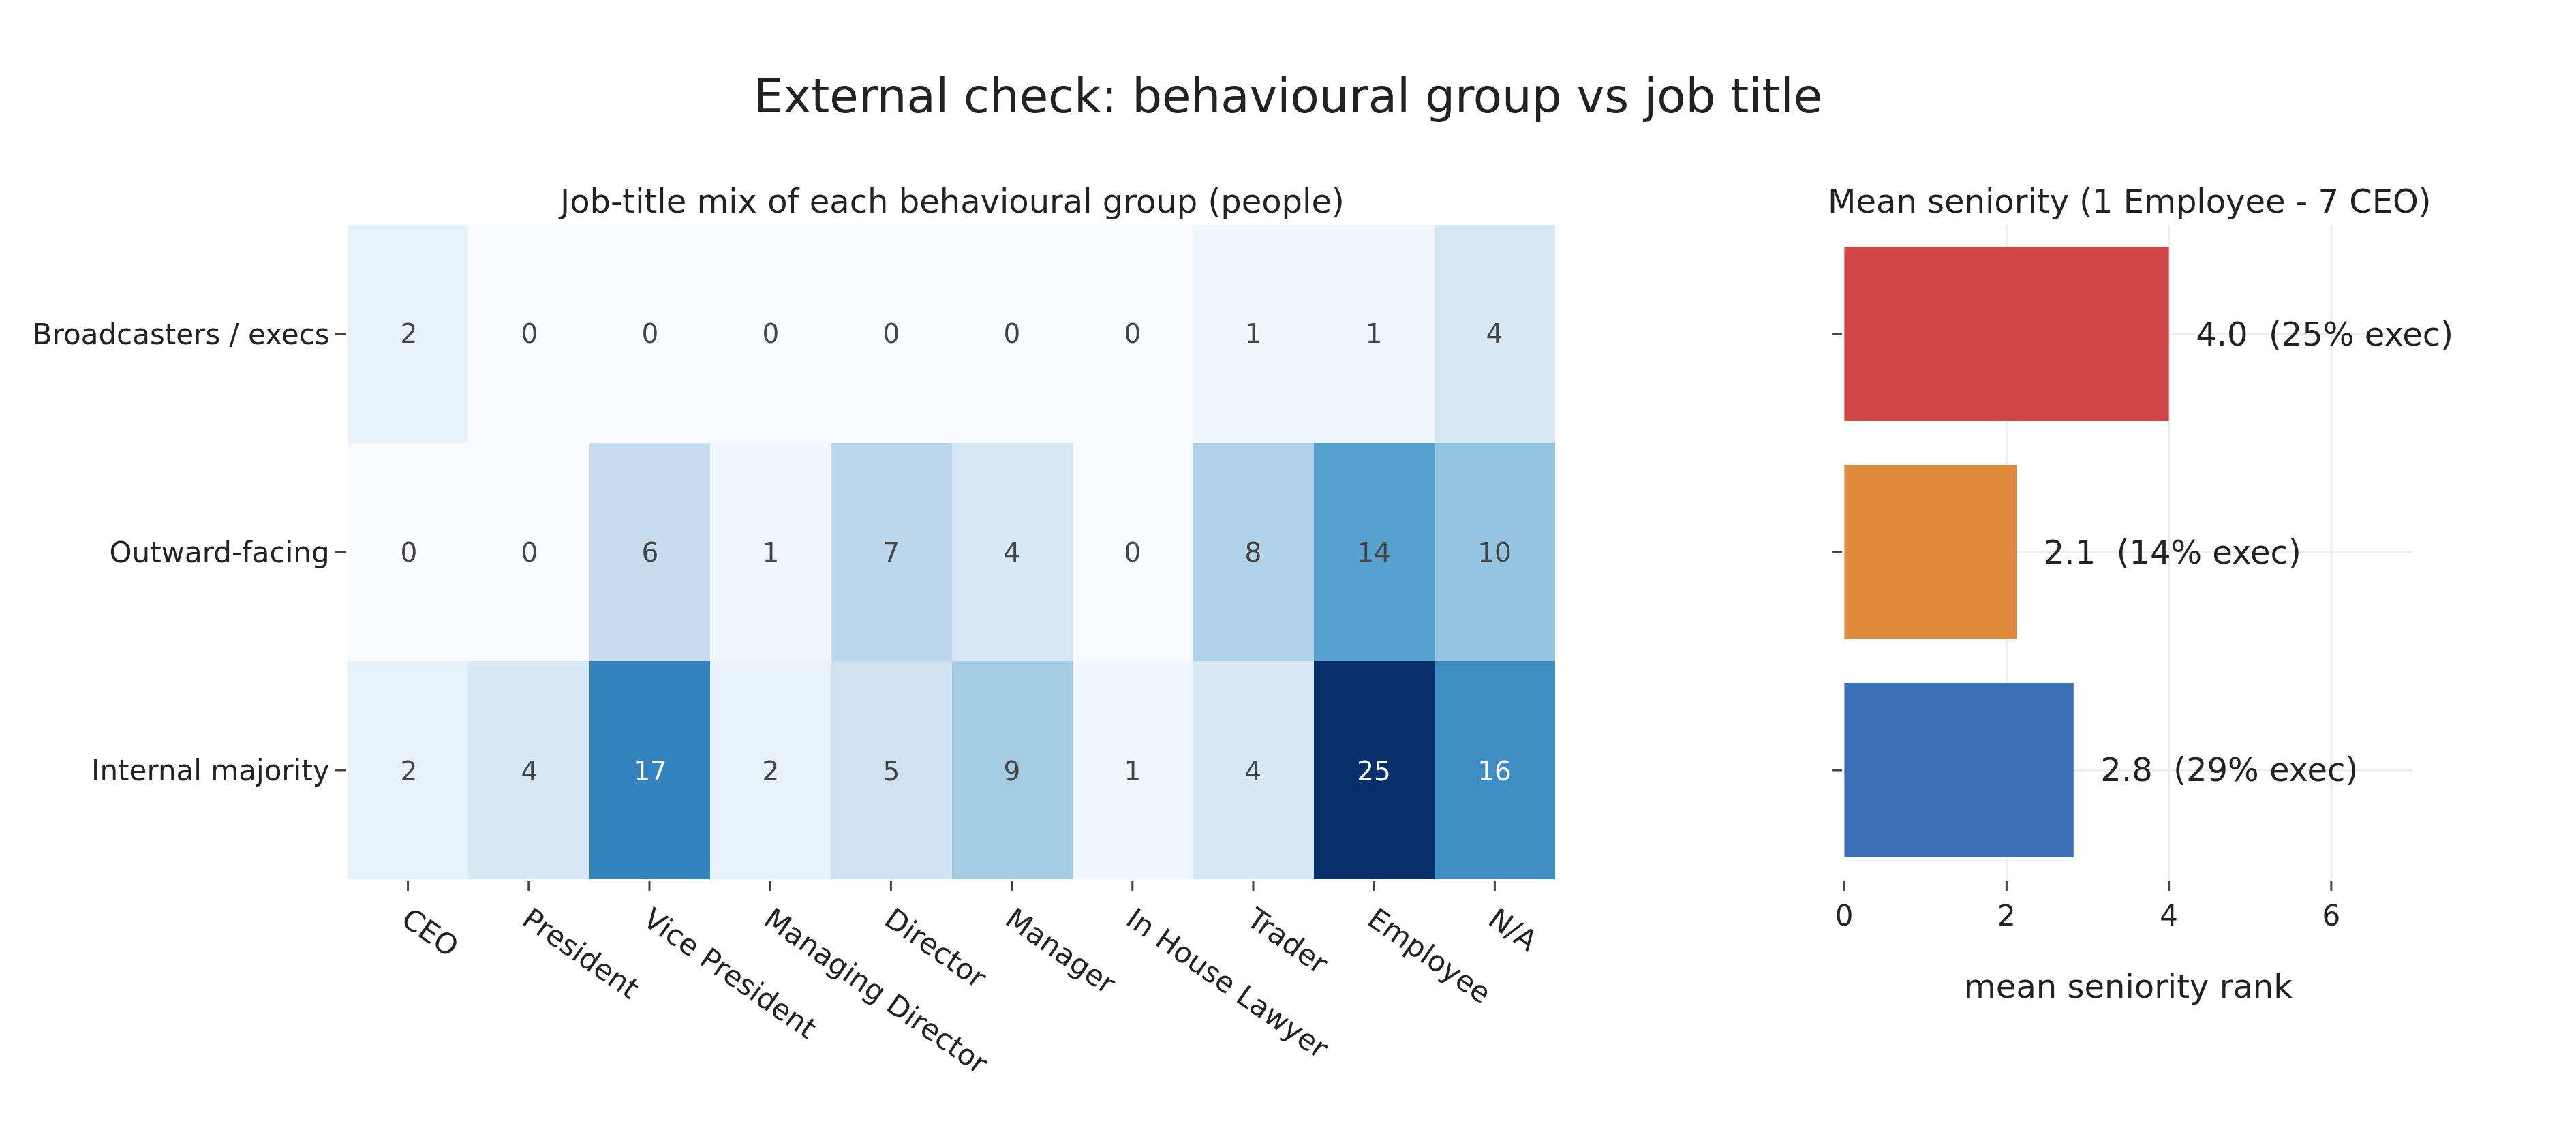

                       n  known  exec_share  mean_seniority
group                                                      
Broadcasters / execs   8      4        0.25             4.0
Internal majority     85     69        0.29            2.83
Outward-facing        50     40        0.14            2.12


In [9]:
roles = pd.read_parquet(CLEAN / "people_roles.parquet")
order = ["Broadcasters / execs", "Outward-facing", "Internal majority"]
dr = pd.DataFrame({"owner": keep, "group": [cl_name[h] for h in keep]}).merge(
    roles[["owner", "title", "seniority_rank", "is_executive"]], on="owner", how="left")
TORDER = ["CEO", "President", "Vice President", "Managing Director", "Director",
          "Manager", "In House Lawyer", "Trader", "Employee", "N/A"]
present = [t for t in TORDER if t in set(dr["title"])]
ctab = (pd.crosstab(dr["group"], dr["title"]).reindex(index=order, columns=present)
        .fillna(0).astype(int))
msen = dr.groupby("group")["seniority_rank"].mean().reindex(order)
exsh = dr.groupby("group")["is_executive"].mean().reindex(order)

fig = make_subplots(rows=1, cols=2, column_widths=[0.68, 0.32], horizontal_spacing=0.14,
    subplot_titles=["Job-title mix of each behavioural group (people)",
                    "Mean seniority (1 Employee - 7 CEO)"])
fig.add_trace(go.Heatmap(z=ctab.values, x=list(ctab.columns), y=list(ctab.index),
    colorscale="Blues", showscale=False, text=ctab.values, texttemplate="%{text}",
    textfont=dict(size=13)), row=1, col=1)
fig.add_trace(go.Bar(y=order, x=[float(msen[g]) for g in order], orientation="h",
    marker_color=[CMAP[g] for g in order], showlegend=False,
    text=[f"  {msen[g]:.1f}  ({exsh[g]:.0%} exec)" for g in order],
    textposition="outside", cliponaxis=False), row=1, col=2)
fig.update_xaxes(tickangle=35, row=1, col=1)
fig.update_xaxes(title_text="mean seniority rank", range=[0, 7], row=1, col=2)
fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_yaxes(autorange="reversed", showticklabels=False, row=1, col=2)
fig.update_layout(title="External check: behavioural group vs job title")
save_fig(fig, "p8_group_vs_title.png", w=1260, h=560,
         margin=dict(l=170, r=80, t=110, b=130))
print(dr.groupby("group").agg(n=("owner", "size"),
      known=("title", lambda s: (s != "N/A").sum()),
      exec_share=("is_executive", "mean"),
      mean_seniority=("seniority_rank", "mean")).round(2).to_string())

## What they write about, and why the next step needs embeddings

The groups above are built from behaviour. The body-to-group prediction the
schedule turns to next will instead work from *content*: given only a message
body, which group of people does it belong to? As a first look we pool each
person's cleaned, non-boilerplate message bodies into one document, turn the 143
documents into TF-IDF vectors over the shared vocabulary, and project them to two
dimensions. Topical structure does exist - a corner of the map is the trading
desk (mmbtu, nymex, deal vocabulary), another is ENA legal (isda, agreement,
counterparty) - but it is faint: a content-only clustering scores a silhouette
near zero, far below the behavioural one. Crucially, when the content map is
coloured by the behavioural group we would want to predict, the groups overlap
almost completely. Bag-of-words shares too much common Enron vocabulary to
separate people; recovering the groups from body text alone is the open problem,
and the reason the next step moves to learned sentence embeddings rather than
word counts.

silhouette  behavioural=0.182   content(TF-IDF)=0.045


/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


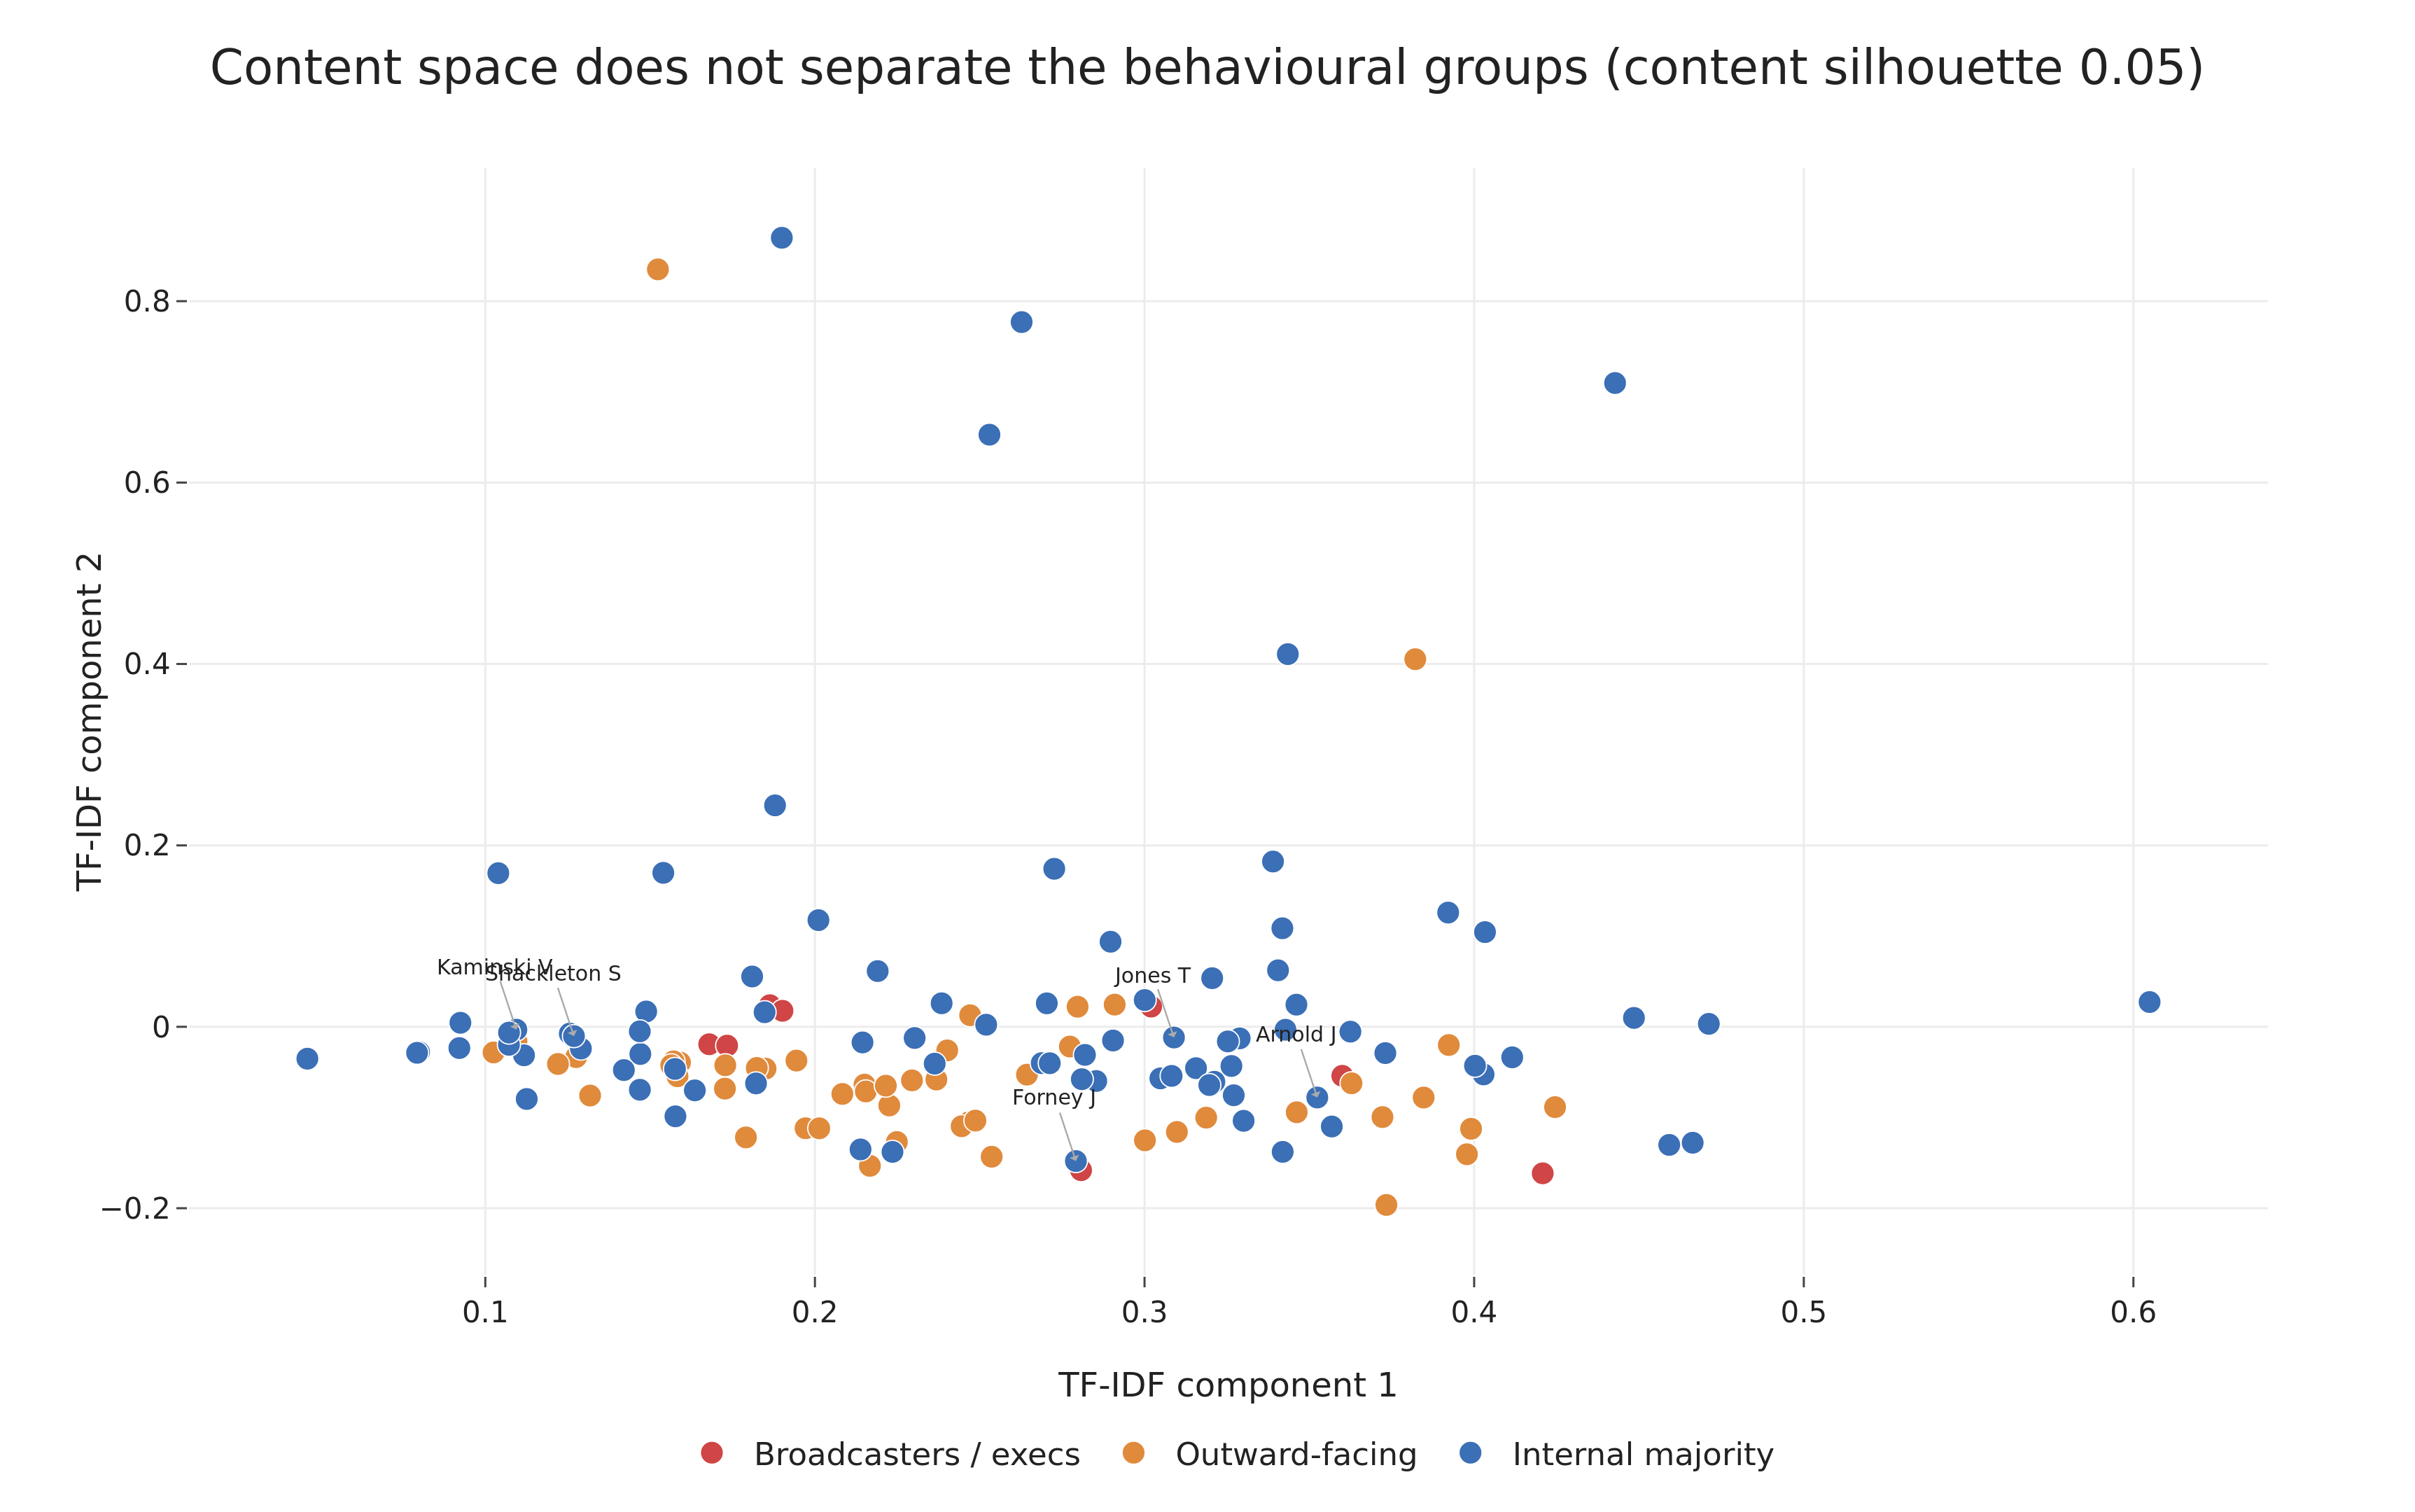


top terms per content cluster (topical structure that does exist):
  cluster 0 (n=27): iso, ferc, bpa, ercot, epmi, transmission, enpower, mws, pdx, epe
  cluster 1 (n=58): dont, mmbtu, html, sitara, socal, ots, phillip, nymex, jason, jay
  cluster 2 (n=19): synchronizing, folder, master, isda, sara, marie, stacy, enronxgate, tana, guaranty
  cluster 3 (n=12): blackberry, handheld, wireless, michelle, kay, rick, lynn, lindy, stan, danny
  cluster 4 (n=27): enronxgate, task, regards, andy, communications, delainey, vince, mmbtu, rob, arnold


In [10]:
gb = authored[(authored["body_chars"] > 0) & (~authored["body_is_boilerplate"])
              & (~authored["body_empty_after_clean"])]
docs = gb.groupby("sender_person")["body"].apply(lambda s: " ".join(s.astype(str))).reindex(keep).fillna("")
tf = TfidfVectorizer(max_features=2000, stop_words="english", min_df=5,
                     max_df=0.6, token_pattern=r"[a-z][a-z]{2,}")
Xc = tf.fit_transform(docs.values)
terms = np.array(tf.get_feature_names_out())
content_k = KMeans(5, n_init=10, random_state=0).fit(Xc)
content_sil = silhouette_score(Xc, content_k.labels_, metric="cosine")
behav_sil = silhouette_score(X, clabel)
print(f"silhouette  behavioural={behav_sil:.3f}   content(TF-IDF)={content_sil:.3f}")

sv = TruncatedSVD(2, random_state=0).fit_transform(Xc)
fig = go.Figure()
for nm, col in CMAP.items():
    idx = [i for i, h in enumerate(keep) if cl_name[h] == nm]
    fig.add_trace(go.Scatter(x=sv[idx, 0], y=sv[idx, 1], mode="markers",
        name=nm, marker=dict(size=11, color=col, line=dict(width=0.6, color="white")),
        text=[disp(keep[i]) for i in idx], hoverinfo="text+name"))
for h in ["arnold-j", "jones-t", "shackleton-s", "kaminski-v", "forney-j"]:
    i = keep.index(h)
    fig.add_annotation(x=sv[i,0], y=sv[i,1], text=disp(h), font=dict(size=10),
                       showarrow=True, arrowwidth=0.8, arrowcolor="#aaaaaa")
fig.update_layout(
    title=f"Content space does not separate the behavioural groups "
          f"(content silhouette {content_sil:.2f})",
    legend=dict(orientation="h", y=-0.13, x=0.5, xanchor="center"))
fig.update_xaxes(title_text="TF-IDF component 1")
fig.update_yaxes(title_text="TF-IDF component 2")
save_fig(fig, "p7_content_overlap.png", w=1150, h=720)

print("\ntop terms per content cluster (topical structure that does exist):")
for c in range(5):
    idx = np.where(content_k.labels_ == c)[0]
    centroid = np.asarray(Xc[idx].mean(axis=0)).ravel()
    top = terms[centroid.argsort()[::-1][:10]]
    print(f"  cluster {c} (n={len(idx)}): {', '.join(top)}")

## What body text actually predicts

The content map suggested the groups overlap; the honest test is to run the
prediction. We label every cleaned message body with its author's behavioural
group and ask a plain TF-IDF plus linear classifier to recover the group,
scoring it on held-out *people* (a group-aware k-fold) so it has to generalise
to authors it never saw. It cannot: about 54% accuracy, below the 64% you reach
by always guessing the internal majority, and the broadcasters are swallowed
whole into that majority. Bag-of-words on the body does not carry the
behavioural group for an unseen person, which is the concrete, supervised
version of the overlap from the content map, and the reason the real prediction
step moves to learned embeddings.

The same vectors tell the opposite story about individuals. Asked which of the
most active people wrote a held-out message, the classifier is right about three
quarters of the time among ten candidates and three fifths among thirty, against
a one-in-ten and one-in-thirty chance. People are highly recognisable from their
own words; their behavioural group is not. That gap is the finding: content is an
individual fingerprint, while the groups are defined by communication structure
(volume, reach, broadcast) that the words barely reflect.

group-pred acc=0.531 macroF1=0.405 majority=0.643
author-id: [(10, 0.751), (20, 0.624), (30, 0.609)]


/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


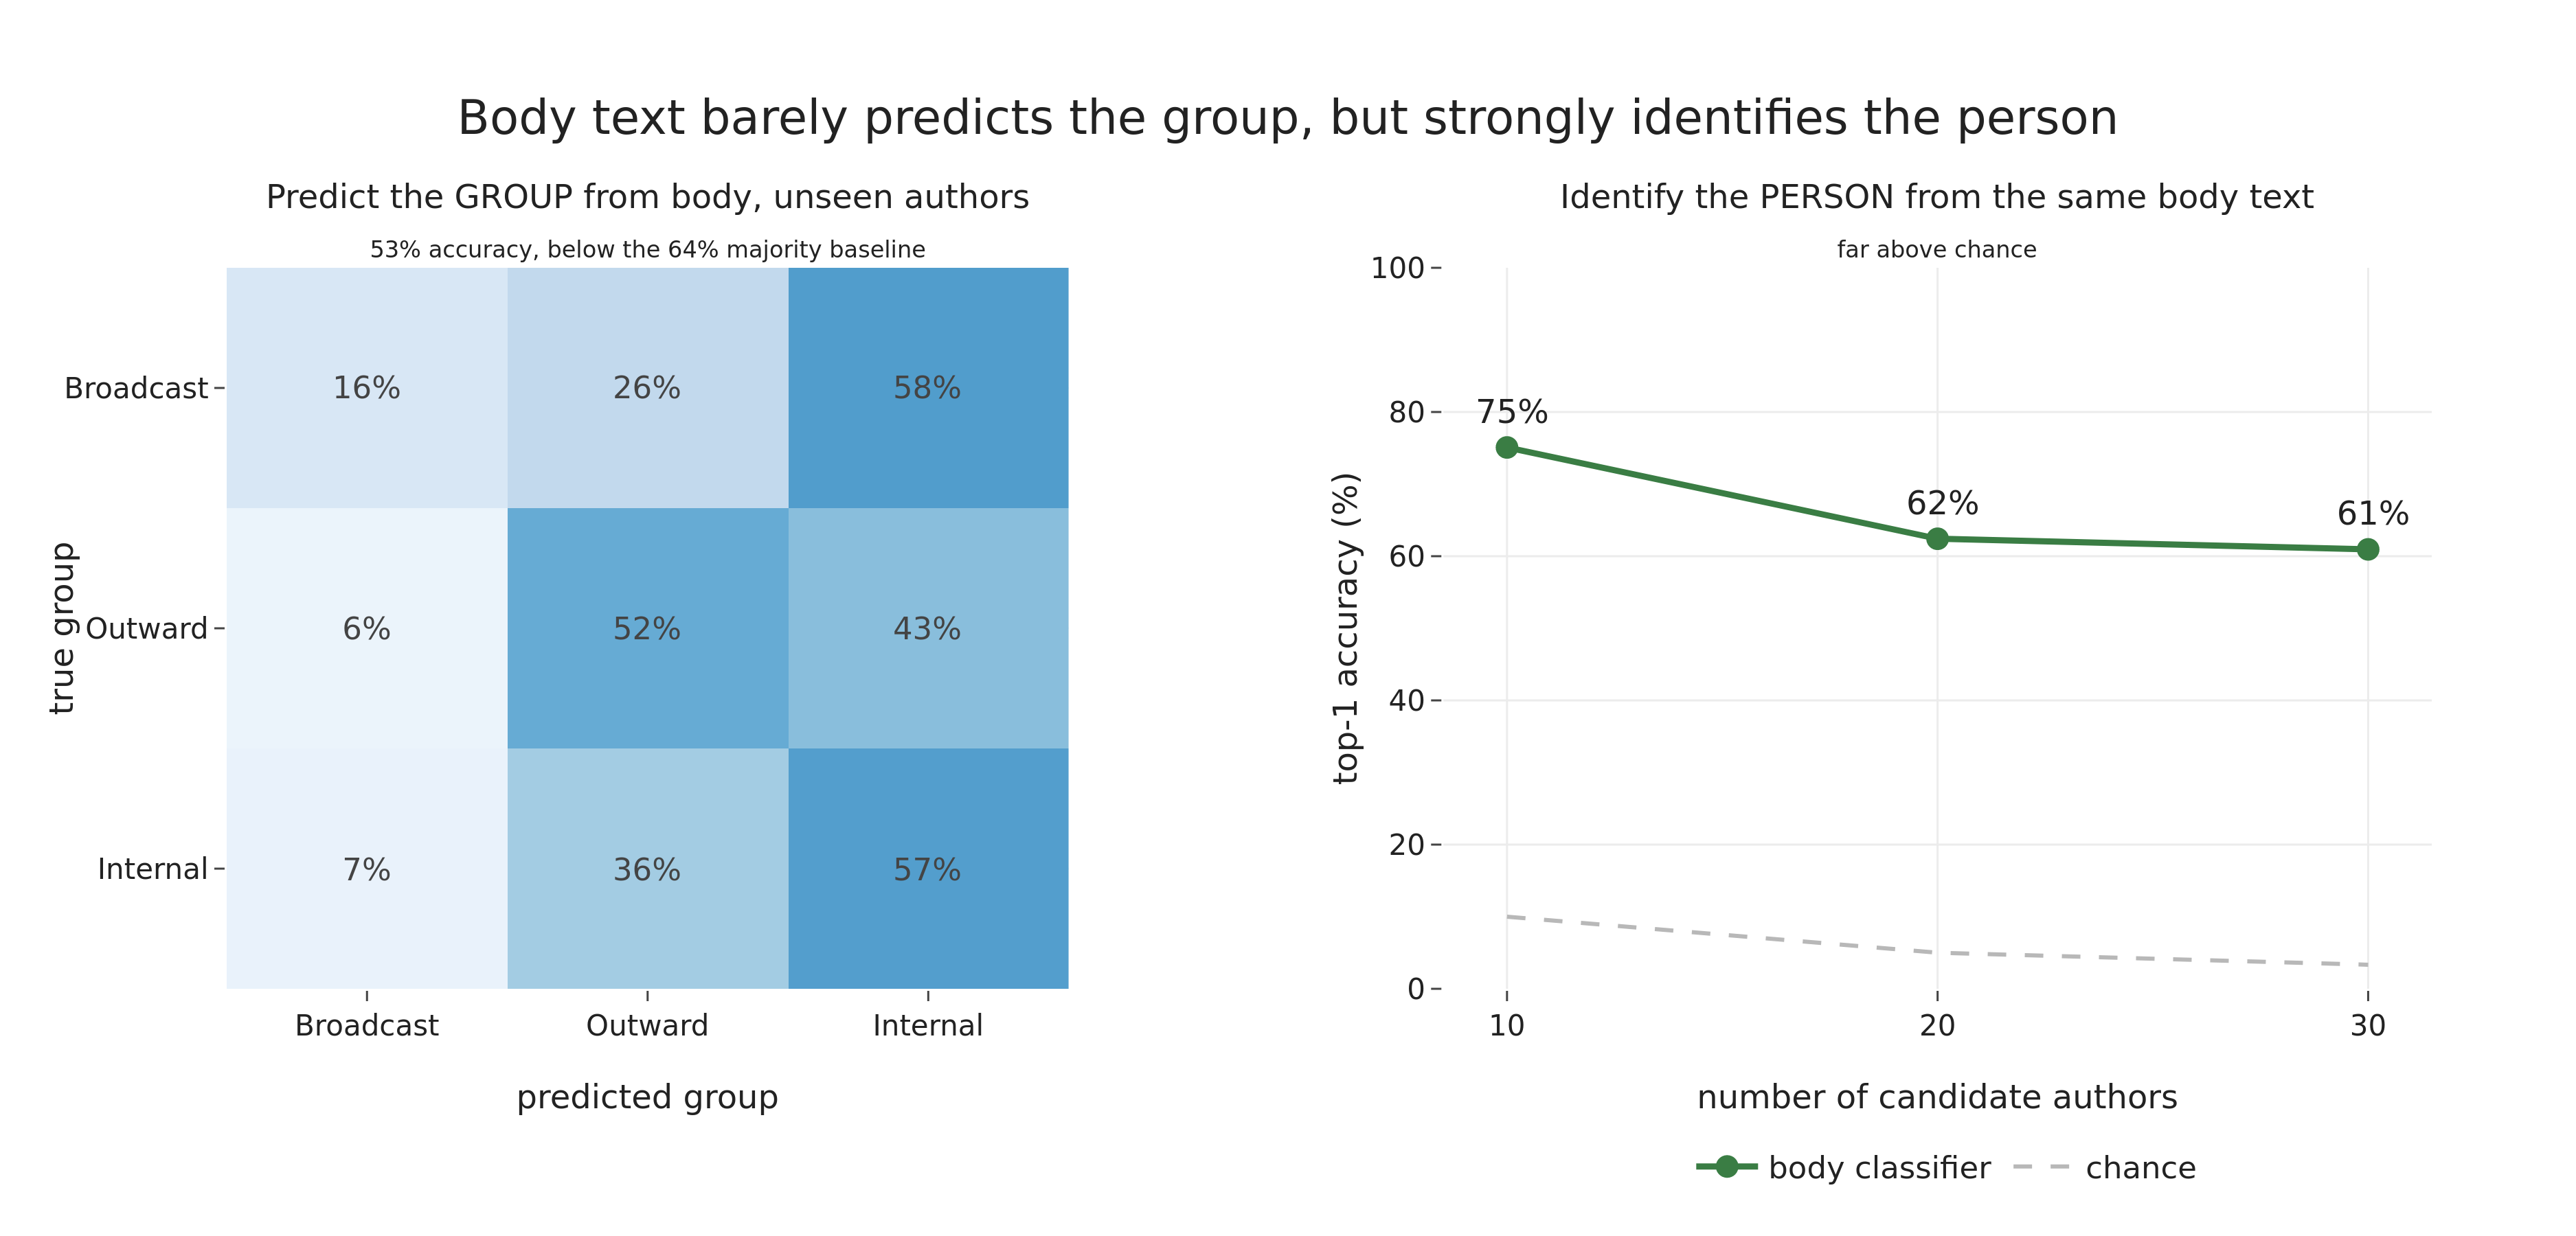

In [11]:
# message-level body corpus, capped per person for balance and speed
gp = authored[(authored["body_chars"] > 0) & (~authored["body_is_boilerplate"])
              & (~authored["body_empty_after_clean"])
              & authored["sender_person"].isin(keep)].copy()
gp = gp.sample(frac=1, random_state=0)
gp["rk"] = gp.groupby("sender_person").cumcount()
gp = gp[gp["rk"] < 120]
texts = gp["body"].astype(str).tolist()
persons = np.asarray(gp["sender_person"].astype(str))
ygrp = np.asarray([cl_name[p] for p in persons], dtype=object)
vec = TfidfVectorizer(max_features=6000, stop_words="english", min_df=5, max_df=0.5,
                      token_pattern=r"[a-z][a-z]{2,}", sublinear_tf=True)
Xm = vec.fit_transform(texts)

GROUPS = ["Broadcasters / execs", "Outward-facing", "Internal majority"]
SHORT = {"Broadcasters / execs": "Broadcast", "Outward-facing": "Outward",
         "Internal majority": "Internal"}
maj = pd.Series(ygrp).value_counts(normalize=True).max()
gp_pred = cross_val_predict(
    LogisticRegression(max_iter=400, C=3, class_weight="balanced"),
    Xm, ygrp, groups=persons, cv=GroupKFold(5))
gp_acc, gp_f1 = accuracy_score(ygrp, gp_pred), f1_score(ygrp, gp_pred, average="macro")
cm = confusion_matrix(ygrp, gp_pred, labels=GROUPS, normalize="true") * 100

ordered = authored.groupby("sender_person").size()[list(keep)].sort_values(
    ascending=False).index.tolist()
Ns, aid = [10, 20, 30], []
for N in Ns:
    m = np.isin(persons, ordered[:N])
    pr = cross_val_predict(LogisticRegression(max_iter=400, C=3), Xm[m], persons[m],
                           cv=StratifiedKFold(5, shuffle=True, random_state=0))
    aid.append(accuracy_score(persons[m], pr))
print(f"group-pred acc={gp_acc:.3f} macroF1={gp_f1:.3f} majority={maj:.3f}")
print("author-id:", list(zip(Ns, [round(x, 3) for x in aid])))

fig = make_subplots(rows=1, cols=2, column_widths=[0.46, 0.54], horizontal_spacing=0.17,
    subplot_titles=[f"Predict the GROUP from body, unseen authors<br>"
                    f"<sub>{gp_acc:.0%} accuracy, below the {maj:.0%} majority baseline</sub>",
                    "Identify the PERSON from the same body text<br>"
                    "<sub>far above chance</sub>"])
gl = [SHORT[g] for g in GROUPS]
fig.add_trace(go.Heatmap(z=cm, x=gl, y=gl, colorscale="Blues", zmin=0, zmax=100,
    text=np.round(cm).astype(int), texttemplate="%{text}%", showscale=False,
    textfont=dict(size=15)), row=1, col=1)
fig.update_xaxes(title_text="predicted group", row=1, col=1)
fig.update_yaxes(title_text="true group", autorange="reversed", row=1, col=1)
fig.add_trace(go.Scatter(x=Ns, y=[a * 100 for a in aid], mode="lines+markers+text",
    marker=dict(size=11, color=GREEN), line=dict(width=3, color=GREEN),
    text=[f" {a:.0%}" for a in aid], textposition="top center",
    name="body classifier"), row=1, col=2)
fig.add_trace(go.Scatter(x=Ns, y=[100 / N for N in Ns], mode="lines",
    line=dict(color=GREY, dash="dash"), name="chance"), row=1, col=2)
fig.update_xaxes(title_text="number of candidate authors", dtick=10, row=1, col=2)
fig.update_yaxes(title_text="top-1 accuracy (%)", range=[0, 100], row=1, col=2)
fig.update_layout(
    title="Body text barely predicts the group, but strongly identifies the person",
    legend=dict(orientation="h", y=-0.20, x=0.78, xanchor="center"))
save_fig(fig, "p9_prediction_baselines.png", w=1250, h=600,
         margin=dict(l=110, r=70, t=130, b=120))

## What makes an individual recognisable

If individuals are that identifiable, what gives them away? For a handful of
well-known people we take the words most over-represented in their own mail
against everyone else's, using a log-odds measure with a shrinkage prior so rare
words do not dominate, and drop each person's own name. Every one resolves into a
clear topic signature: Kaminski into research, risk and Rice; Dasovich into
California, the state and electricity; Tana Jones into counterparties and ISDA
masters; John Arnold into NYMEX and volatility; Forney into ERCOT and the
power desk; Lokay into pipeline capacity and the Waha hub. These are the
differences between individual persons that the author-identification score was
picking up, and the raw material a per-person embedding will encode more fully.

/tmp/ipykernel_2711069/2215422797.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


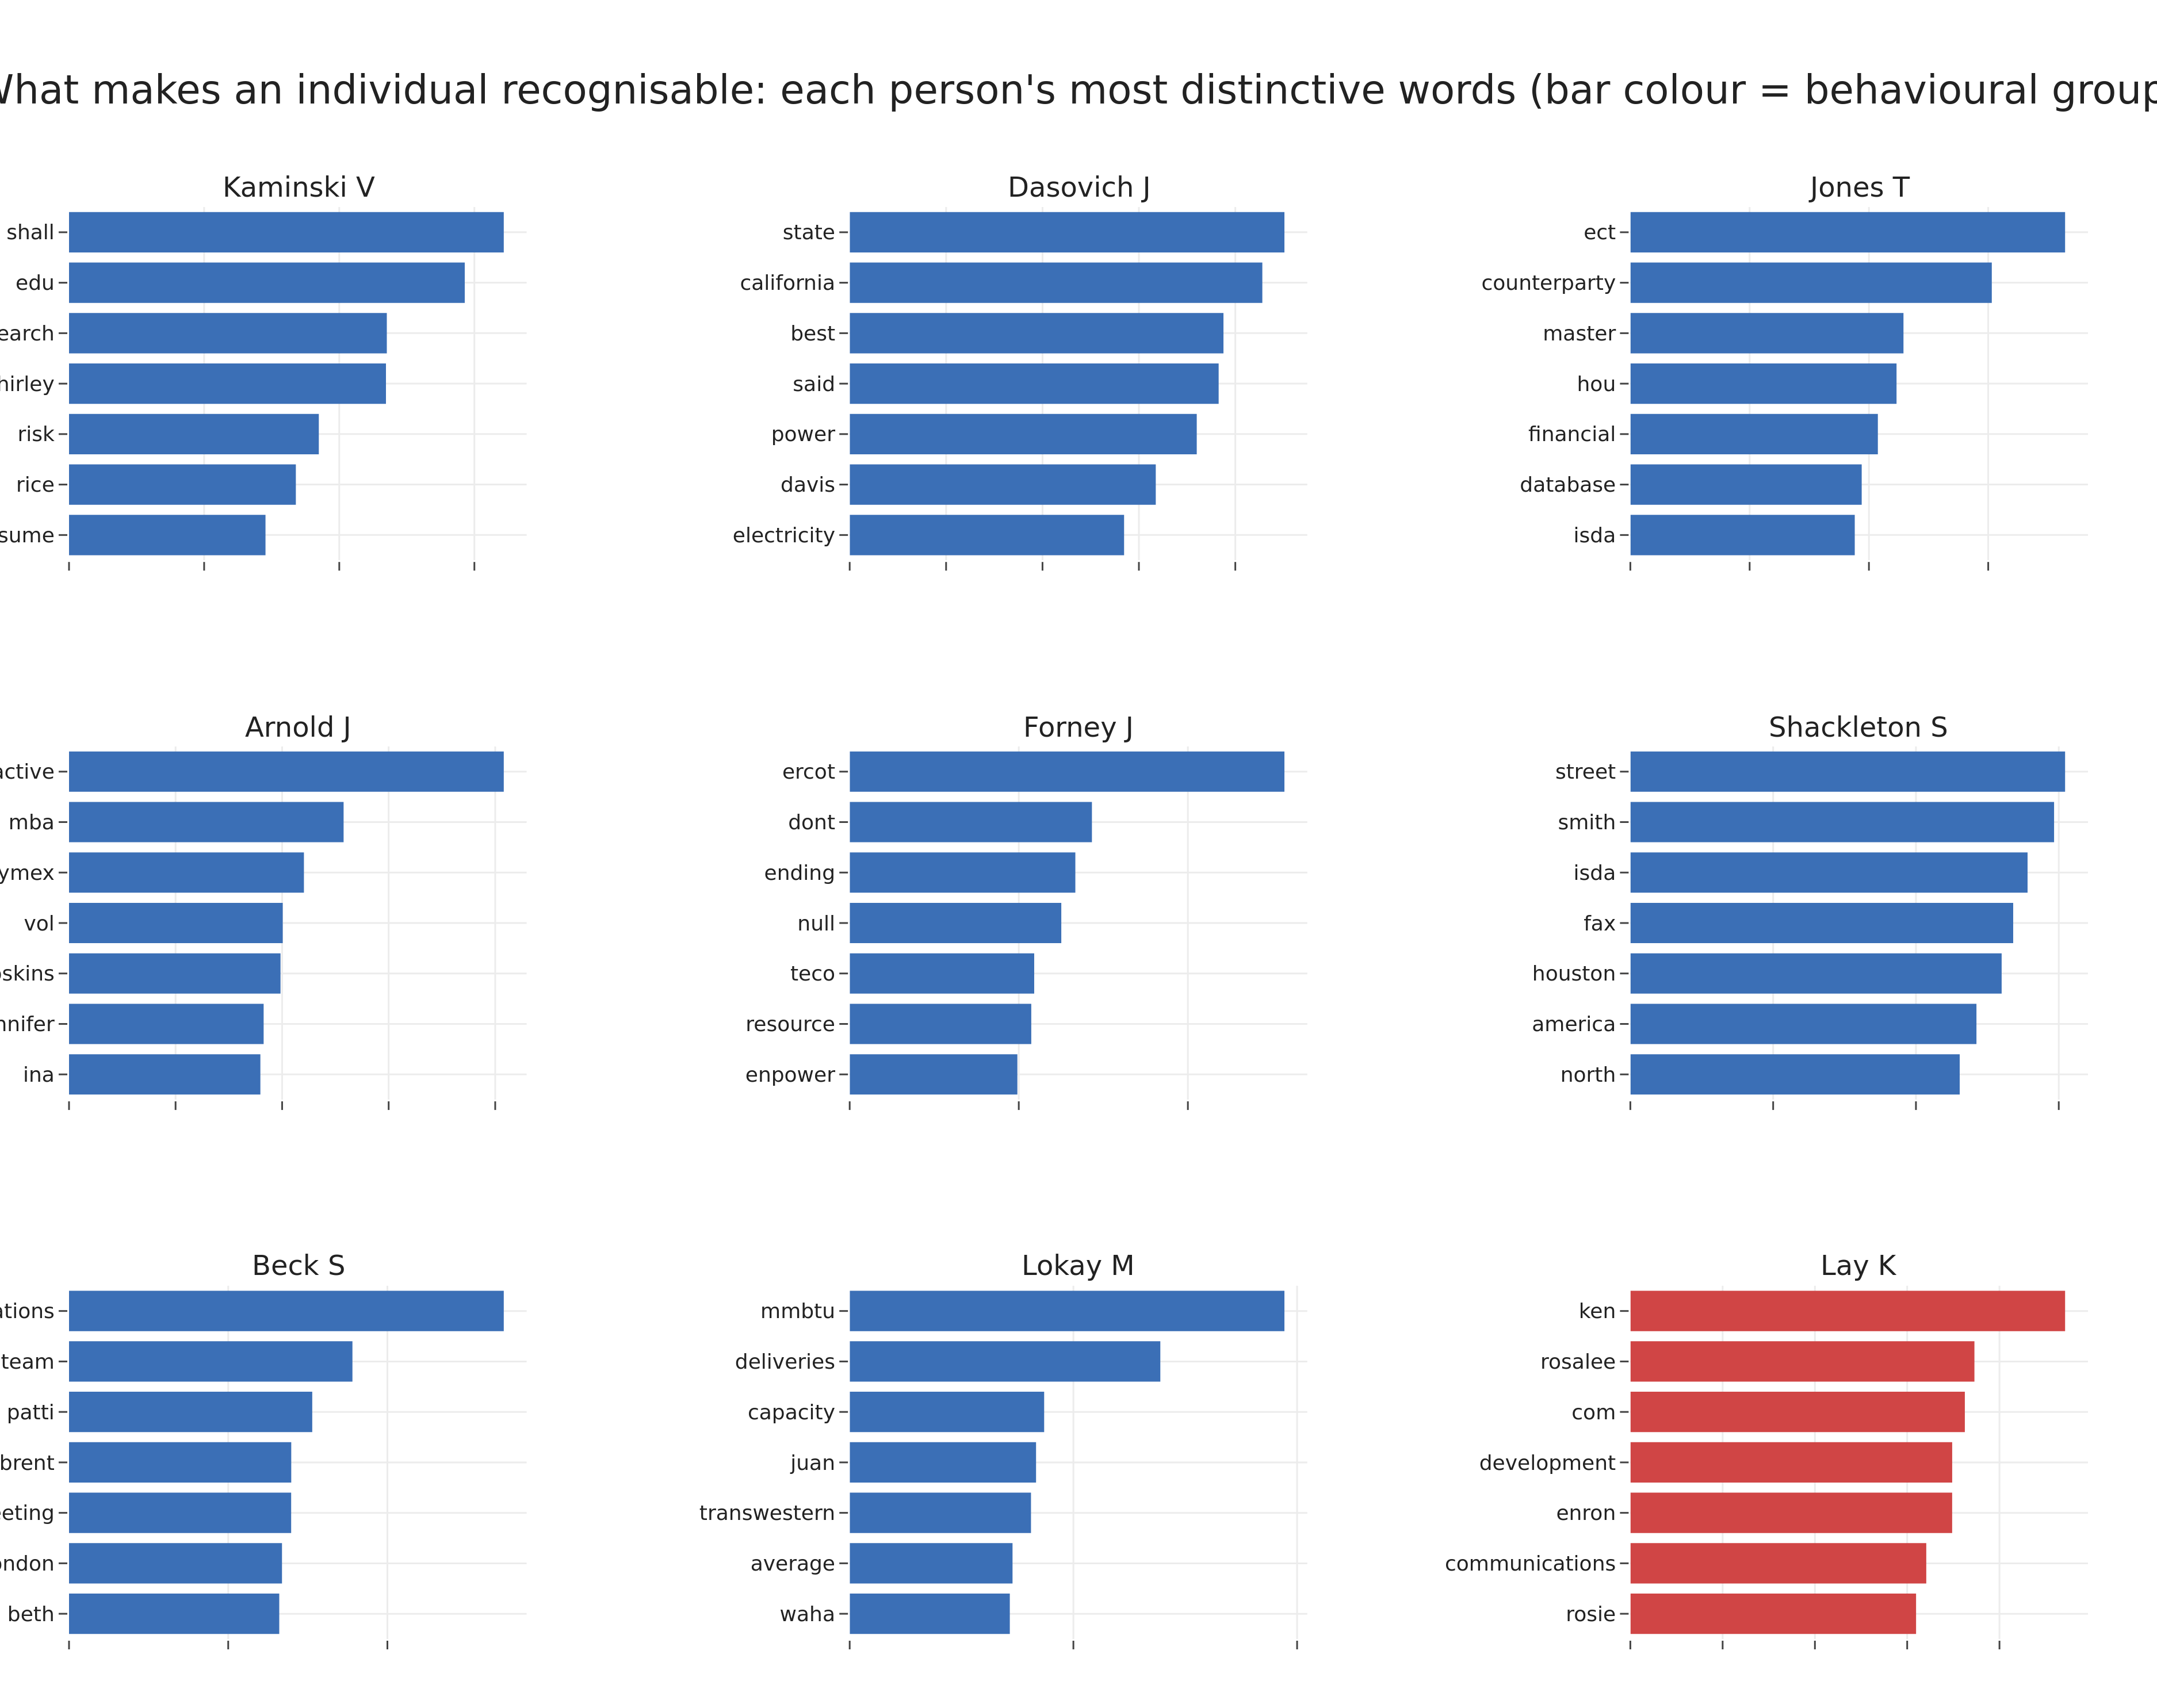

In [12]:
cv = CountVectorizer(max_features=4000, stop_words="english", min_df=8,
                     token_pattern=r"[a-z][a-z]{2,}")
pdocs = (authored[(authored["body_chars"] > 0) & (~authored["body_is_boilerplate"])
         & (~authored["body_empty_after_clean"]) & authored["sender_person"].isin(keep)]
         .groupby("sender_person")["body"].apply(lambda s: " ".join(s.astype(str))))
Cc = cv.fit_transform(pdocs.values)
vv = np.array(cv.get_feature_names_out())
tot = np.asarray(Cc.sum(0)).ravel(); Ntot = tot.sum(); A0 = 2000.0; aw = A0 * tot / Ntot
pidx = {p: i for i, p in enumerate(pdocs.index)}
# tokens to suppress per person: their own first/last name, so the chart shows
# topical distinctiveness rather than the fact that they sign their own name
NAMES = {r.owner: ({t for t in str(r.first_name).lower().split()}
                   | {t for t in str(r.last_name).lower().split()})
         for r in roles.itertuples()}

def distinct_words(p, k=7):
    yi = np.asarray(Cc[pidx[p]].todense()).ravel(); ni = yi.sum()
    yr = tot - yi; nr = Ntot - ni
    d = (np.log((yi + aw) / (ni + A0 - yi - aw))
         - np.log((yr + aw) / (nr + A0 - yr - aw)))
    z = d / np.sqrt(1 / (yi + aw) + 1 / (yr + aw))
    own = set(disp(p).lower().split()) | {p.split("-")[0]} | NAMES.get(p, set())
    out = [(vv[j], float(z[j])) for j in z.argsort()[::-1] if vv[j] not in own][:k]
    return out[::-1]

PEOPLE = [p for p in ["kaminski-v", "dasovich-j", "jones-t", "arnold-j", "forney-j",
          "shackleton-s", "beck-s", "lokay-m", "lay-k"] if p in pidx]
ncol = 3; nrow = math.ceil(len(PEOPLE) / ncol)
fig = make_subplots(rows=nrow, cols=ncol, horizontal_spacing=0.16, vertical_spacing=0.13,
    subplot_titles=[f"{disp(p)}" for p in PEOPLE])
for i, p in enumerate(PEOPLE):
    r, c = i // ncol + 1, i % ncol + 1
    ws = distinct_words(p, 7)
    col = CMAP[cl_name[p]] if p in cl_name else BLUE
    fig.add_trace(go.Bar(y=[w for w, _ in ws], x=[z for _, z in ws], orientation="h",
        marker_color=col, showlegend=False), row=r, col=c)
    fig.update_xaxes(showticklabels=False, row=r, col=c)
    fig.update_yaxes(tickfont=dict(size=12), row=r, col=c)
fig.update_layout(
    title="What makes an individual recognisable: each person's most distinctive words "
          "(bar colour = behavioural group)")
save_fig(fig, "p10_distinctive_words.png", w=1250, h=330 * nrow,
         margin=dict(l=40, r=40, t=120, b=40))

## Open ends

The three behavioural groups are descriptive roles read off a soft gradient, not
hard categories; the modest silhouette is the honest summary, and a person near a
boundary could reasonably belong to either side. Two executive desks resolve to
an assistant's address (Ken Lay's to Rosalee Fleming, one Whalley desk to Liz
Taylor), so "authored by" for those mailboxes means "sent from that desk", which
is right for a behavioural reading but a caveat for content. The standing
coverage caveat still applies: only the 149 released mailboxes have a full
two-sided profile, and the people they wrote to are seen from one side.

The next step is the body-to-group prediction. The baseline here marks out the
hard part precisely: a word-count classifier identifies the individual author
well but lands below the majority baseline on the behavioural group for unseen
people, so the work is to encode each body with a sentence-embedding model and
see whether the group boundary, which plain words miss, becomes learnable in that
space. The individual fingerprints are already strong, so the open question is
not whether people are distinguishable but whether their writing carries the
structural role the groups are built on, or whether predicting that role needs
behavioural signal alongside the text.